# Chain Grouping, Selection Models and LLM Payload Experiments

Этот ноутбук — основной экспериментальный контур для ВКР: здесь мы сравниваем способы группировки событий, строим признаки, формируем soft-labels и обучаем модели отбора эпизодов.

Главное разделение:

- **все 51 матча EURO 2024** используются для табличных экспериментов: стратегии группировки, признаки, soft-labels, LogReg/CatBoost/TabNet, ranking;
- **финальный speak-набор матчей** используется позже для дорогого LLM/TTS-прогона и ручного анализа комментариев.

Почему так:

- обучение и сравнение эвристик/моделей лучше делать на максимально широком наборе матчей;
- LLM-вызовы дорогие, поэтому их разумно запускать только на выбранном speak-наборе матчей;
- качество всей системы оценивается не одной метрикой, а цепочкой проверок: структура эпизодов -> soft-labels -> модели отбора -> LLM-комментарии -> пригодность к озвучке.

API-блоки выключены по умолчанию. Ноутбук можно запускать сверху вниз без обращения к LLM, пока флаги `RUN_*_API` равны `False`.


## Методология эксперимента

Сравниваем несколько способов собрать события StatsBomb в эпизоды:

1. `event_only`: каждое событие отдельно.
2. `related_only`: компоненты связности по `related_events` без нарезки.
3. `related_cap`: `related_events` + ограничения по числу событий, длительности и gap.
4. `related_stop_cap`: `related_cap` + остановка на смысловых stop-events: удар, фол, офсайд, потеря, перехват, вынос, действие вратаря.
5. `time_window`: фиксированное временное окно.
6. `possession_cap`: группировка по владению с ограничениями.

Для каждой стратегии считаем:

- число payloads, которые потенциально уйдут в LLM;
- медианную длину цепочки и P90 длины;
- длительность цепочек;
- распределение soft-labels;
- размер JSON-payload;
- качество LogReg/CatBoost/TabNet относительно soft-labels;
- feature importance, reduced features, PCA/SHAP;
- ranking-метрики для выбора top-K эпизодов внутри матча.

Важно: soft-labels — это не ручная gold-разметка, а экспертная proxy-разметка. Поэтому модели здесь учатся воспроизводить эвристику отбора эпизодов. Финальная проверка качества комментария делается отдельно через LLM и ручной просмотр подвыборки.


## Карта эксперимента: что сравниваем и зачем

В этом ноутбуке есть несколько разных сравнений. Их нельзя смешивать, потому что они отвечают на разные вопросы.

### Главный вопрос работы

Как из потока событий StatsBomb получить короткие эпизоды, которые можно отправить в LLM и превратить в тифлокомментарий?

Для этого нужно сравнить три уровня:

1. **Группировка событий**: как собрать события в эпизоды.
2. **Отбор эпизодов**: какие эпизоды достойны комментария.
3. **LLM-комментарий**: насколько выбранные эпизоды хорошо комментируются.

### Что является основным результатом

Основной результат для ВКР — не то, что CatBoost получил высокий F1 на soft-labels. Это ожидаемо, потому что soft-labels построены формулой.

Основной результат должен быть таким:

- выбран способ группировки событий;
- объяснено, почему он лучше альтернатив;
- показано, что он даёт цепочки разумной длины;
- показано, что по этим цепочкам можно отбирать важные эпизоды;
- показано, что LLM по таким payload генерирует более пригодные комментарии.

### Что НЕ надо утверждать

Не надо писать:

> CatBoost с macro-F1=0.99 идеально решает задачу выбора эпизодов.

Правильнее:

> Высокое качество CatBoost на soft-labels показывает, что признаки хорошо воспроизводят экспертную эвристику. Однако финальная пригодность стратегии проверяется отдельно через LLM-комментарии и ручной анализ подвыборки.


In [99]:
# --- Experiment map for thesis ---
# Эта таблица нужна как шпаргалка: что сравниваем, чем измеряем, как интерпретируем.

EXPERIMENT_PLAN_DF = pd.DataFrame([
    {
        'block': 'A. Grouping structure',
        'question': 'Какая стратегия даёт цепочки разумной длины?',
        'compared': 'event_only / related_only / related_cap / related_stop_cap / time_window / possession_cap',
        'metrics': 'chains_n, events_median, events_p90, duration_median, duration_p90, json_chars_mean',
        'main_artifact': 'grouping_strategy_stats.csv',
        'interpretation': 'Слишком короткие цепочки дают мало контекста, слишком длинные дороги и путают LLM.',
    },
    {
        'block': 'B. Soft-label distribution',
        'question': 'Как стратегия влияет на долю skip/brief/must?',
        'compared': 'strategies by soft_label_3 and soft_label_5',
        'metrics': 'crosstab(strategy, soft_label_3), crosstab(strategy, soft_label_5)',
        'main_artifact': 'df_chains / diagnostics tables',
        'interpretation': 'Если стратегия производит слишком много skip или must, она может быть несбалансированной.',
    },
    {
        'block': 'C. Selector model sanity-check',
        'question': 'Модели воспроизводят эвристику или находят более общие закономерности?',
        'compared': 'LogReg / CatBoost on full vs reduced feature sets',
        'metrics': 'macro-F1, balanced_accuracy, confusion_matrix',
        'main_artifact': 'leaderboard_by_grouping.csv, honest_feature_set_eval.csv',
        'interpretation': 'Full score около 0.99 ожидаем, reduced-наборы показывают, насколько результат зависит от прямых rule-признаков.',
    },
    {
        'block': 'D. Feature interpretation',
        'question': 'Какие признаки реально влияют на модель?',
        'compared': 'full CatBoost features',
        'metrics': 'CatBoost feature importance, optional SHAP',
        'main_artifact': 'catboost_feature_importance.csv',
        'interpretation': 'Используется для объяснимости, а не как финальная оценка качества.',
    },
    {
        'block': 'E. Ranking',
        'question': 'Можно ли выбрать top-K эпизодов внутри матча?',
        'compared': 'RuleSoftLabel / LogRegProbability / optional ranker',
        'metrics': 'NDCG@K, Precision@K, Recall@K',
        'main_artifact': 'ranking_metrics.csv',
        'interpretation': 'Нужно, если есть ограниченный бюджет комментариев или LLM-токенов.',
    },
    {
        'block': 'F. LLM evaluation',
        'question': 'Какая стратегия группировки лучше комментируется LLM?',
        'compared': 'same LLM prompt across grouping strategies',
        'metrics': 'json_valid, time_bounds_match, commented_types_valid, word_count, est_tts_sec, LLM-judge scores',
        'main_artifact': 'llm_grouping_eval/grouping_llm_leaderboard.csv',
        'interpretation': 'Это главный практический критерий выбора стратегии для комментария.',
    },
    {
        'block': 'G. TTS readiness',
        'question': 'Можно ли потом озвучить комментарии?',
        'compared': 'LLM outputs',
        'metrics': 'word_count, est_tts_sec, sentence_count, no_forbidden_temporal',
        'main_artifact': 'LLM eval outputs / commentary_for_tts.csv',
        'interpretation': 'Комментарий должен быть не только верным, но и пригодным для аудиодорожки.',
    },
])

display(EXPERIMENT_PLAN_DF)
EXPERIMENT_PLAN_DF.to_csv(OUT_DIR / 'experiment_plan_for_vkr.csv', index=False)


,block,question,compared,metrics,main_artifact,interpretation
0,A. Grouping structure,Какая стратегия даёт цепочки разумной длины?,event_only / related_only / related_cap / rela...,"chains_n, events_median, events_p90, duration_...",grouping_strategy_stats.csv,"Слишком короткие цепочки дают мало контекста, ..."
1,B. Soft-label distribution,Как стратегия влияет на долю skip/brief/must?,strategies by soft_label_3 and soft_label_5,"crosstab(strategy, soft_label_3), crosstab(str...",df_chains / diagnostics tables,Если стратегия производит слишком много skip и...
2,C. Selector model sanity-check,Модели воспроизводят эвристику или находят бол...,LogReg / CatBoost on full vs reduced feature sets,"macro-F1, balanced_accuracy, confusion_matrix","leaderboard_by_grouping.csv, honest_feature_se...","Full score около 0.99 ожидаем, reduced-наборы ..."
3,D. Feature interpretation,Какие признаки реально влияют на модель?,full CatBoost features,"CatBoost feature importance, optional SHAP",catboost_feature_importance.csv,"Используется для объяснимости, а не как финаль..."
4,E. Ranking,Можно ли выбрать top-K эпизодов внутри матча?,RuleSoftLabel / LogRegProbability / optional r...,"NDCG@K, Precision@K, Recall@K",ranking_metrics.csv,"Нужно, если есть ограниченный бюджет комментар..."
5,F. LLM evaluation,Какая стратегия группировки лучше комментирует...,same LLM prompt across grouping strategies,"json_valid, time_bounds_match, commented_types...",llm_grouping_eval/grouping_llm_leaderboard.csv,Это главный практический критерий выбора страт...
6,G. TTS readiness,Можно ли потом озвучить комментарии?,LLM outputs,"word_count, est_tts_sec, sentence_count, no_fo...",LLM eval outputs / commentary_for_tts.csv,"Комментарий должен быть не только верным, но и..."


In [100]:
from pathlib import Path
import sys
import os
import re
import json
import math
import time
import hashlib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from statsbomb_toolkit.sber_exports import preprocessing

try:
    from catboost import CatBoostClassifier, CatBoostRanker, Pool
    HAS_CATBOOST = True
except Exception as e:
    HAS_CATBOOST = False
    print('CatBoost unavailable:', e)

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    HAS_TABNET = True
except Exception as e:
    HAS_TABNET = False
    print('TabNet unavailable:', e)

sns.set_theme(style='whitegrid', context='talk')

try:
    from statsbomb_toolkit.gigachat import GigaChatClient
    HAS_GIGACHAT_CLIENT = True
except Exception as e:
    HAS_GIGACHAT_CLIENT = False
    print('GigaChatClient unavailable:', e)


## Конфигурация

Здесь фиксируется ключевой дизайн эксперимента.

- `index_all.csv` содержит все 51 матча EURO 2024. Именно он используется для обучения и сравнения моделей.
- `index_to_speak_top15.csv` остаётся справочным списком матчей-кандидатов для озвучки.
- `FINAL_LLM_MATCH_IDS` — обязательный speak-набор матчей, который потом пойдёт в LLM/TTS-прогон.

Параметры нарезки цепочек:

- `MAX_EVENTS_PER_CHAIN = 6`: не даём LLM слишком длинные эпизоды;
- `MAX_CHAIN_DURATION_SEC = 10`: ограничиваем длительность одного эпизода;
- `MAX_GAP_SEC = 2.5`: если между соседними событиями большой разрыв, начинаем новый эпизод;
- `TIME_WINDOW_SEC = 8`: размер окна для стратегии `time_window`.

Сначала запускаем табличные эксперименты на всех 51 матчах. LLM-блоки ниже отдельно фильтруют только обязательный speak-набор матчей.


In [101]:
PROCESSED_DIR = ROOT / 'outputs' / 'euro2024_all' / 'processed_json'
INDEX_ALL = PROCESSED_DIR / 'index_all.csv'
INDEX_TOP15 = PROCESSED_DIR / 'index_to_speak_top15.csv'

OUT_DIR = ROOT / 'outputs' / 'chain_grouping_llm_model_experiments'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = OUT_DIR / 'tables'
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Табличные эксперименты и обучение моделей делаем на всех 51 матчах.
TRAIN_INDEX_PATH = INDEX_ALL
TRAIN_SCOPE = 'all_51_matches'

# Эти матчи потом пойдут в финальный LLM/TTS-прогон.
# Если захочешь заменить набор — меняешь только этот список.
FINAL_LLM_MATCH_IDS = {
    '3930158',  # Germany - Scotland, opening match
    '3943043',  # Spain - England, final
    '3942752',  # Spain - France, semi-final
    '3942819',  # Netherlands - England, semi-final
    '3942226',  # Spain - Germany, quarter-final
    '3942349',  # Portugal - France, quarter-final
}

RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.20

MAX_EVENTS_PER_CHAIN = 6
MAX_CHAIN_DURATION_SEC = 10.0
MAX_GAP_SEC = 2.5
TIME_WINDOW_SEC = 8.0

MIN_SOFT_LABEL_FOR_LLM = 1
TARGET = 'soft_label_3'

RUN_TABNET = False
RUN_SHAP = False
RUN_API = False

index_path = TRAIN_INDEX_PATH
print('train index:', index_path)
print('train scope:', TRAIN_SCOPE)
print('speak-set LLM matches:', sorted(FINAL_LLM_MATCH_IDS))


train index: /Users/angelina23/Documents/ml-ami/outputs/euro2024_all/processed_json/index_all.csv
train scope: all_51_matches
speak-set LLM matches: ['3930158', '3942226', '3942349', '3942752', '3942819', '3943043']


## Загрузка уже стандартизированных JSON

Здесь мы не скачиваем и не стандартизируем данные заново. Используем готовые артефакты из `outputs/euro2024_all/processed_json`:

- `events_std` — события после стандартизации координат;
- `events_std_clean` — очищенные события для payload;
- `sb360_std` — стандартизированный 360-контекст;
- `bad_ids` — события, для которых 360 намеренно отключается;
- `meta` — метаданные матча, команды, стадия, reference-team по таймам.

Этот блок должен загрузить **51 матч** из `index_all.csv`. Если матчей меньше, значит надо проверить путь к `index_all.csv`.


In [102]:
def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

manifest = pd.read_csv(index_path)
manifest['match_id'] = manifest['match_id'].astype(str)
manifest['is_final_llm_match'] = manifest['match_id'].isin(FINAL_LLM_MATCH_IDS).astype(int)

prepared_by_match = {}
for _, row in manifest.iterrows():
    mid = str(row['match_id'])
    meta = load_json(row['meta'])
    ref_by_period = {int(k): v for k, v in (meta.get('ref_by_period') or {}).items()}
    prepared_by_match[mid] = {
        'events_std': load_json(row['events_std']),
        'events_std_clean': load_json(row['events_std_clean']),
        'sb360_std': load_json(row['sb360_std']),
        'bad_ids': set(load_json(row['bad_ids'])),
        'meta': meta,
        'ref_by_period': ref_by_period,
        'is_final_llm_match': int(mid in FINAL_LLM_MATCH_IDS),
    }

summary_df = pd.DataFrame([
    {
        'match_id': mid,
        'teams': ' - '.join(pack['meta'].get('teams', [])),
        'stage': pack['meta'].get('stage') or 'EURO 2024',
        'events': len(pack['events_std']),
        'sb360': len(pack['sb360_std']),
        'bad_ids': len(pack['bad_ids']),
        'to_speak_top15': pack['meta'].get('to_speak', 0),
        'final_llm_match': pack['is_final_llm_match'],
    }
    for mid, pack in prepared_by_match.items()
]).sort_values(['final_llm_match', 'match_id'], ascending=[False, True])

print('matches loaded:', len(prepared_by_match))
print('final LLM matches loaded:', int(summary_df['final_llm_match'].sum()))
display(summary_df.head(20))

summary_df.to_csv(TAB_DIR / 'loaded_matches_summary.csv', index=False)


matches loaded: 51
final LLM matches loaded: 6


,match_id,teams,stage,events,sb360,bad_ids,to_speak_top15,final_llm_match
0,3930158,Germany - Scotland,EURO 2024,3373,3088,133,1,1
8,3942226,Spain - Germany,EURO 2024,4463,4025,186,1,1
10,3942349,Portugal - France,EURO 2024,5190,4489,173,1,1
12,3942752,Spain - France,EURO 2024,3328,2942,185,1,1
13,3942819,Netherlands - England,EURO 2024,3485,2951,105,1,1
14,3943043,Spain - England,EURO 2024,3312,2852,164,1,1
15,3930159,Hungary - Switzerland,EURO 2024,3356,3017,163,0,0
16,3930160,Spain - Croatia,EURO 2024,3796,3237,173,0,0
17,3930161,Italy - Albania,EURO 2024,4066,3462,96,0,0
18,3930162,Slovenia - Denmark,EURO 2024,3509,3120,196,0,0


## Вспомогательные функции времени и related-графа

`gap_sec` — это разрыв между соседними событиями в потенциальной цепочке:

\[
gap_i = t_i - t_{i-1}.
\]

Если gap больше порога, цепочка разрезается. Это нужно, чтобы формально связанные, но уже временно оторванные события не попадали в один LLM-эпизод.


In [103]:
def to_seconds(ts):
    if not isinstance(ts, str):
        return None
    m = re.match(r'^(\d+):(\d+):(\d+)(?:\.(\d+))?$', ts.strip())
    if not m:
        return None
    hh, mm, ss, ms = m.groups()
    return int(hh) * 3600 + int(mm) * 60 + int(ss) + (float(f'0.{ms}') if ms else 0.0)


def event_type(ev):
    t = ev.get('type') or {}
    return t.get('name') if isinstance(t, dict) else t


def play_pattern(ev):
    p = ev.get('play_pattern') or {}
    return p.get('name') if isinstance(p, dict) else p


def event_time(ev):
    return to_seconds(ev.get('timestamp'))


def build_related_graph(events_std):
    events_by_id = {e.get('id'): e for e in events_std if e.get('id')}
    outgoing = defaultdict(set)
    incoming = defaultdict(set)
    for e in events_std:
        eid = e.get('id')
        if not eid:
            continue
        for rid in (e.get('related_events') or []):
            if rid:
                outgoing[eid].add(rid)
                incoming[rid].add(eid)
    neighbors = {eid: set() for eid in events_by_id}
    for eid in events_by_id:
        neighbors[eid] |= outgoing.get(eid, set())
        neighbors[eid] |= incoming.get(eid, set())
    return events_by_id, neighbors


## Стратегии группировки: что означает каждая

В словаре `GROUPING_STRATEGIES` каждому названию соответствует функция, которая берёт список событий матча и возвращает список цепочек.

Когда Python печатает что-то вроде

```python
{'event_only': <function ...>, 'related_cap': <function ...>}
```

это значит: слева имя стратегии, справа функция, которая её реализует.

### `event_only`

Минимальный baseline: одно событие = одна цепочка.

Пример:

```text
Pass, Ball Receipt*, Carry, Shot
```

превращается в:

```text
[Pass]
[Ball Receipt*]
[Carry]
[Shot]
```

Плюсы: просто, легко анализировать.  
Минусы: почти нет контекста; пас отделяется от приёма; LLM может давать слишком бедные комментарии.

### `related_only`

События объединяются по графу `related_events` из StatsBomb без дополнительных ограничений.

Пример:

```text
Pass -> Ball Receipt*
Shot -> Block
Duel -> Ball Recovery
```

становится:

```text
[Pass, Ball Receipt*]
[Shot, Block]
[Duel, Ball Recovery]
```

Плюсы: использует нативные связи StatsBomb.  
Минусы: иногда компоненты получаются слишком длинными.

### `related_cap`

Сначала строим цепочки по `related_events`, затем режем слишком длинные цепочки по ограничениям:

```python
MAX_EVENTS_PER_CHAIN = 6
MAX_CHAIN_DURATION_SEC = 10
MAX_GAP_SEC = 2.5
```

Цепочка режется, если:

- в ней уже слишком много событий;
- она длится слишком долго;
- между соседними событиями слишком большой временной разрыв.

Это основной практический baseline: сохраняет связи StatsBomb, но защищает LLM от слишком длинного входа.

### `related_stop_cap`

Это `related_cap` плюс футбольные стоп-события.

Цепочка дополнительно завершается на событиях:

```text
Shot, Foul, Offside, Interception, Ball Recovery,
Dispossessed, Miscontrol, Clearance, Goal Keeper,
Block, Error
```

Идея: удар, фол, офсайд, потеря или перехват часто являются естественным концом эпизода.

Это главный кандидат на финальную стратегию, потому что она сочетает:

- связи StatsBomb;
- ограничение длины;
- футбольную логику завершения эпизода.

### `time_window`

События группируются только по фиксированному временному окну, например 8 секунд.

Плюсы: просто и удобно для аудио.  
Минусы: окно не знает футбольных связей, поэтому может разрезать `Pass + Ball Receipt*` или склеить несвязанные события.

### `possession_cap`

События группируются внутри владения (`period + possession`), а затем режутся по ограничениям длины, длительности и gap.

Плюсы: футбольно логично, потому что владение часто соответствует фазе атаки.  
Минусы: владения бывают длинными, поэтому без ограничений эта стратегия даёт слишком большие цепочки.

### Что сравниваем между стратегиями

Для каждой стратегии дальше считаем:

- количество цепочек;
- длину цепочек;
- длительность цепочек;
- размер LLM-payload;
- распределение `soft_label_3` и `soft_label_5`;
- качество LogReg/CatBoost/TabNet;
- качество LLM-комментариев на фиксированной подвыборке.

Иными словами, стратегия группировки выбирается не только по модели отбора, но и по тому, насколько хорошо такие цепочки потом комментируются LLM.


In [104]:
STOP_TYPES = {
    'Shot', 'Offside', 'Foul Committed', 'Foul Won', 'Interception', 'Ball Recovery',
    'Dispossessed', 'Miscontrol', 'Clearance', 'Goal Keeper', 'Block', 'Error',
    'Own Goal For', 'Own Goal Against'
}


def sorted_events(events_std):
    return sorted(events_std, key=lambda e: (e.get('period') or 0, e.get('index', 10**9), e.get('id') or ''))


def split_chain_by_caps(chain, events_by_id, max_events=6, max_duration_sec=10.0, max_gap_sec=2.5, stop_types=False):
    chunks, cur = [], []
    t0, prev_t = None, None

    def flush():
        nonlocal cur, t0, prev_t
        if cur:
            chunks.append(cur)
        cur, t0, prev_t = [], None, None

    for eid in chain:
        ev = events_by_id[eid]
        t = event_time(ev)
        et = event_type(ev)

        if not cur:
            cur = [eid]
            t0 = t
            prev_t = t
            continue

        need_cut = False
        if len(cur) >= max_events:
            need_cut = True
        if t is not None and t0 is not None and (t - t0) > max_duration_sec:
            need_cut = True
        if t is not None and prev_t is not None and (t - prev_t) > max_gap_sec:
            need_cut = True

        if need_cut:
            flush()
            cur = [eid]
            t0 = t
            prev_t = t
        else:
            cur.append(eid)
            prev_t = t

        if stop_types and et in STOP_TYPES and len(cur) >= 2:
            flush()

    flush()
    return chunks


def chains_event_only(events_std, **kwargs):
    events_by_id = {e.get('id'): e for e in events_std if e.get('id')}
    return [[e.get('id')] for e in sorted_events(events_std) if e.get('id')], events_by_id


def chains_related_components(events_std, cap=False, stop_types=False, **kwargs):
    events_by_id, neighbors = build_related_graph(events_std)
    all_ids = set(events_by_id)
    used = set()
    chains = []

    def expand(root_id):
        group = set()
        stack = [root_id]
        while stack:
            cur = stack.pop()
            if not cur or cur in group or cur in used:
                continue
            group.add(cur)
            for nb in neighbors.get(cur, set()):
                if nb in all_ids and nb not in group and nb not in used:
                    stack.append(nb)
        return group

    for e in sorted_events(events_std):
        eid = e.get('id')
        if not eid or eid in used:
            continue
        group = expand(eid)
        chain = sorted(group, key=lambda x: events_by_id[x].get('index', 10**9))
        used.update(chain)
        if cap:
            chains.extend(split_chain_by_caps(
                chain, events_by_id,
                max_events=kwargs.get('max_events', MAX_EVENTS_PER_CHAIN),
                max_duration_sec=kwargs.get('max_duration_sec', MAX_CHAIN_DURATION_SEC),
                max_gap_sec=kwargs.get('max_gap_sec', MAX_GAP_SEC),
                stop_types=stop_types,
            ))
        else:
            chains.append(chain)
    return chains, events_by_id


def chains_time_window(events_std, window_sec=8.0, max_events=6, **kwargs):
    events_by_id = {e.get('id'): e for e in events_std if e.get('id')}
    chains, cur = [], []
    win_start = None
    for e in sorted_events(events_std):
        eid = e.get('id')
        if not eid:
            continue
        t = event_time(e)
        if not cur:
            cur = [eid]
            win_start = t
            continue
        need_cut = False
        if len(cur) >= max_events:
            need_cut = True
        if t is not None and win_start is not None and (t - win_start) > window_sec:
            need_cut = True
        if need_cut:
            chains.append(cur)
            cur = [eid]
            win_start = t
        else:
            cur.append(eid)
    if cur:
        chains.append(cur)
    return chains, events_by_id


def chains_possession_cap(events_std, max_events=6, max_duration_sec=10.0, max_gap_sec=2.5, **kwargs):
    events_by_id = {e.get('id'): e for e in events_std if e.get('id')}
    grouped = defaultdict(list)
    for e in sorted_events(events_std):
        eid = e.get('id')
        if not eid:
            continue
        key = (e.get('period'), e.get('possession'))
        grouped[key].append(eid)
    chains = []
    for key in sorted(grouped.keys()):
        chain = grouped[key]
        chains.extend(split_chain_by_caps(chain, events_by_id, max_events, max_duration_sec, max_gap_sec, stop_types=True))
    return chains, events_by_id


GROUPING_STRATEGIES = {
    'event_only': lambda evs: chains_event_only(evs),
    'related_only': lambda evs: chains_related_components(evs, cap=False),
    'related_cap': lambda evs: chains_related_components(evs, cap=True, stop_types=False),
    'related_stop_cap': lambda evs: chains_related_components(evs, cap=True, stop_types=True),
    'time_window': lambda evs: chains_time_window(evs, window_sec=TIME_WINDOW_SEC, max_events=MAX_EVENTS_PER_CHAIN),
    'possession_cap': lambda evs: chains_possession_cap(evs),
}


## Сбор payload для каждой стратегии

Для каждой стратегии строим цепочки и превращаем их в LLM-payload через `preprocessing.build_chain_payload_v4`.

Это важно: разные стратегии группировки получают одинаковую дальнейшую обработку. Значит, сравнение честнее: меняется только способ объединения событий.


In [105]:
def build_payloads_for_strategy(strategy_name, prepared_by_match):
    strategy_fn = GROUPING_STRATEGIES[strategy_name]
    payloads = []
    chain_rows = []

    for mid, pack in prepared_by_match.items():
        chains, events_by_id = strategy_fn(pack['events_std'])
        events_clean_by_id = {e.get('id'): ce for e, ce in zip(pack['events_std'], pack['events_std_clean']) if e.get('id')}
        sb360_by_id = {(s.get('event_uuid') or s.get('id')): s for s in pack['sb360_std'] if (s.get('event_uuid') or s.get('id'))}

        for local_idx, ch in enumerate(chains, start=1):
            payload = preprocessing.build_chain_payload_v4(
                ch,
                events_by_id=events_by_id,
                events_clean_by_id=events_clean_by_id,
                sb360_by_id=sb360_by_id,
                bad_ids=set(pack['bad_ids']),
                ref_by_period=pack['ref_by_period'],
            )
            payload['match_id'] = mid
            payload['strategy'] = strategy_name
            payload['local_chain_idx'] = local_idx
            payload['stage'] = pack['meta'].get('stage') or 'EURO 2024'
            payload['to_speak'] = int(pack['meta'].get('to_speak', 0))
            payloads.append(payload)
            chain_rows.append({'match_id': mid, 'strategy': strategy_name, 'local_chain_idx': local_idx, 'events_n': len(ch)})

    return payloads, pd.DataFrame(chain_rows)

STRATEGIES_TO_RUN = ['event_only', 'related_only', 'related_cap', 'related_stop_cap', 'time_window', 'possession_cap']

payloads_by_strategy = {}
chain_index_by_strategy = {}
for st in STRATEGIES_TO_RUN:
    payloads, chain_index = build_payloads_for_strategy(st, prepared_by_match)
    payloads_by_strategy[st] = payloads
    chain_index_by_strategy[st] = chain_index
    print(st, 'payloads:', len(payloads))


event_only payloads: 187858
related_only payloads: 19261
related_cap payloads: 49300
related_stop_cap payloads: 52431
time_window payloads: 34599
possession_cap payloads: 47605


## Сравнение геометрии цепочек

До обучения моделей нужно понять, что вообще дала стратегия группировки.

Смотрим:

- сколько цепочек получилось;
- среднюю/медианную/P90 длину;
- среднюю/медианную/P90 длительность;
- примерный размер JSON в символах.

Если стратегия создаёт слишком длинные payload, LLM будет дороже и менее стабильной. Если слишком короткие — комментарии будут бедными.


,strategy,chains_n,events_mean,events_median,events_p90,duration_mean,duration_median,duration_p90,json_chars_mean,json_chars_p90
0,event_only,187858,1.000000,1.0,1.0,0.000000,0.000,0.000,3667.737403,4450.0
5,possession_cap,47605,3.946182,4.0,6.0,2.033043,1.834,4.474,13596.924609,23743.6
2,related_cap,49300,3.810507,4.0,6.0,1.916122,1.666,4.345,13136.825254,23592.0
1,related_only,19261,9.753284,4.0,26.0,8.558520,2.458,25.532,33159.748040,90036.0
3,related_stop_cap,52431,3.582957,3.0,6.0,1.801951,1.499,4.300,12375.216208,23465.0
4,time_window,34599,5.429579,6.0,6.0,4.000923,3.961,6.813,18591.586289,24266.0


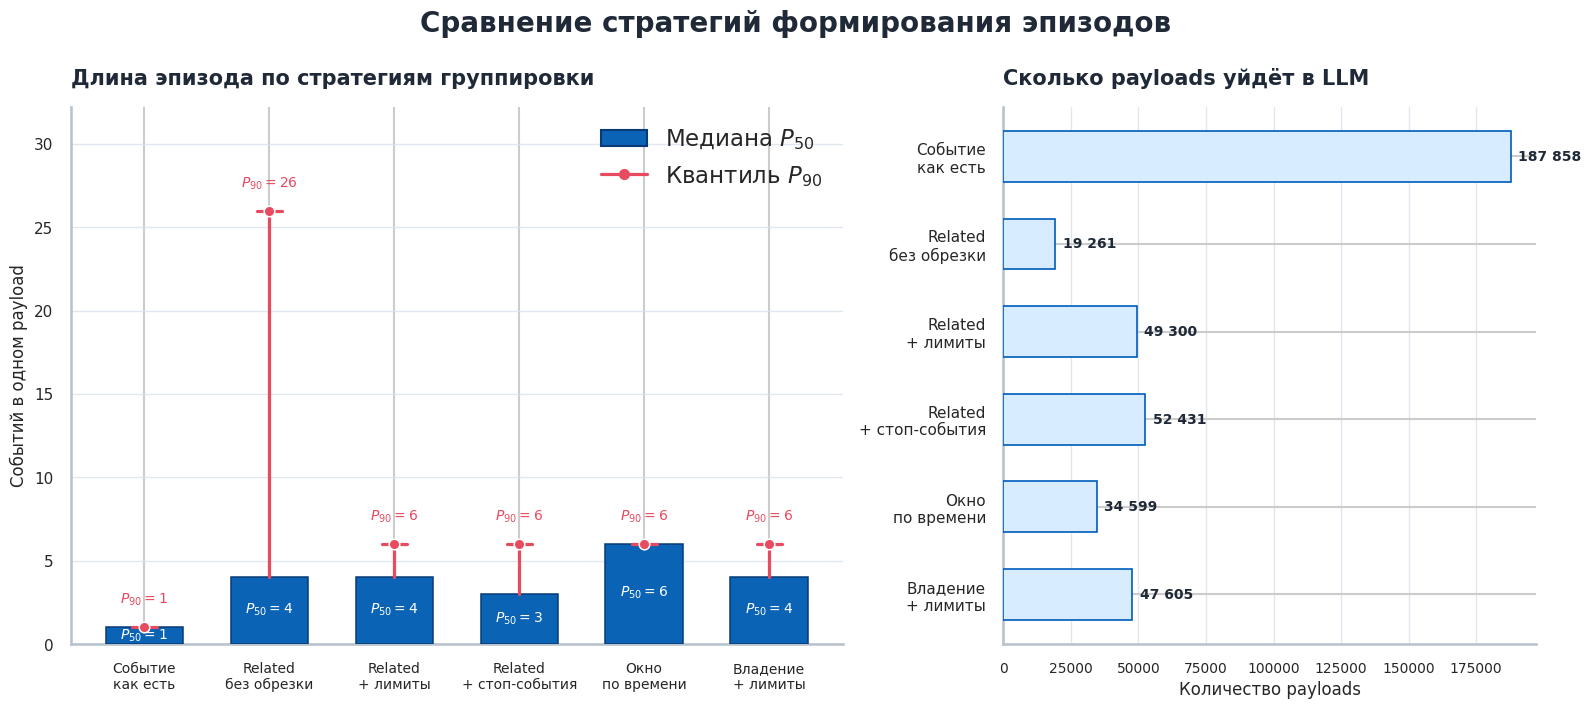

saved: /Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments/figures/grouping_strategy_compactness.png


In [107]:
def payload_duration_sec(p):
    events = p.get('events') or []
    if not events:
        return 0.0
    t0 = to_seconds(((events[0].get('event_json') or {}).get('timestamp')))
    t1 = to_seconds(((events[-1].get('event_json') or {}).get('timestamp')))
    return max(0.0, (t1 - t0)) if (t0 is not None and t1 is not None) else 0.0


def strategy_stats(payloads_by_strategy):
    rows = []
    for st, payloads in payloads_by_strategy.items():
        lens = np.array([len(p.get('events', [])) for p in payloads], dtype=float)
        durs = np.array([payload_duration_sec(p) for p in payloads], dtype=float)
        sizes = np.array([len(json.dumps(p, ensure_ascii=False)) for p in payloads], dtype=float)
        rows.append({
            'strategy': st,
            'chains_n': len(payloads),
            'events_mean': lens.mean() if len(lens) else 0,
            'events_median': np.median(lens) if len(lens) else 0,
            'events_p90': np.percentile(lens, 90) if len(lens) else 0,
            'duration_mean': durs.mean() if len(durs) else 0,
            'duration_median': np.median(durs) if len(durs) else 0,
            'duration_p90': np.percentile(durs, 90) if len(durs) else 0,
            'json_chars_mean': sizes.mean() if len(sizes) else 0,
            'json_chars_p90': np.percentile(sizes, 90) if len(sizes) else 0,
        })
    return pd.DataFrame(rows).sort_values('strategy')


stats_df = strategy_stats(payloads_by_strategy)
display(stats_df)
stats_df.to_csv(TAB_DIR / 'grouping_strategy_stats.csv', index=False)

# --- presentation plot: chain compactness by grouping strategy ---
# Для ВКР/презентации важно показать не только медианную длину,
# но и хвост (P90): именно длинные цепочки чаще всего путают LLM.
plot_df = stats_df.copy()
strategy_order = [
    'event_only', 'related_only', 'related_cap',
    'related_stop_cap', 'time_window', 'possession_cap'
]
plot_df['strategy'] = pd.Categorical(plot_df['strategy'], categories=strategy_order, ordered=True)
plot_df = plot_df.sort_values('strategy').reset_index(drop=True)

label_ru = {
    'event_only': 'Событие\nкак есть',
    'related_only': 'Related\nбез обрезки',
    'related_cap': 'Related\n+ лимиты',
    'related_stop_cap': 'Related\n+ стоп-события',
    'time_window': 'Окно\nпо времени',
    'possession_cap': 'Владение\n+ лимиты',
}
plot_df['strategy_ru'] = plot_df['strategy'].astype(str).map(label_ru).fillna(plot_df['strategy'].astype(str))

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.titlesize': 15,
    'xtick.labelsize': 10,
    'ytick.labelsize': 11,
    'mathtext.fontset': 'dejavusans',
})

hse_blue = '#005BBB'
bar_blue = '#0B63B6'
light_blue = '#D7ECFF'
accent = '#E84A5F'
grid = '#D9E2EC'
text = '#1F2937'

fig, axes = plt.subplots(
    1, 2,
    figsize=(15.8, 6.4),
    gridspec_kw={'width_ratios': [1.45, 1.0]},
    constrained_layout=True,
)
fig.patch.set_facecolor('white')
fig.suptitle(
    'Сравнение стратегий формирования эпизодов',
    x=0.5, y=1.04, ha='center', va='bottom',
    fontsize=20, fontweight='bold', color=text,
)

# Левая панель: типичная длина и хвост распределения.
ax = axes[0]
x = np.arange(len(plot_df))
median = plot_df['events_median'].to_numpy(dtype=float)
p90 = plot_df['events_p90'].to_numpy(dtype=float)
ymax = max(float(np.nanmax(p90)) if len(p90) else 1.0, 1.0)

bars = ax.bar(
    x,
    median,
    width=0.62,
    color=bar_blue,
    edgecolor='#083B75',
    linewidth=1.1,
    label=r'Медиана $P_{50}$',
    zorder=3,
)

# P90: вертикальный отрезок + точка + небольшой cap, чтобы квантиль читался как отдельная статистика.
for xi, med, q90 in zip(x, median, p90):
    ax.plot([xi, xi], [med, q90], color=accent, linewidth=2.3, zorder=4)
    ax.plot([xi - 0.10, xi + 0.10], [q90, q90], color=accent, linewidth=2.3, zorder=4)
    ax.scatter([xi], [q90], s=58, color=accent, edgecolor='white', linewidth=1.1, zorder=5)

for xi, med, q90 in zip(x, median, p90):
    if med > 0:
        ax.text(
            xi,
            max(med * 0.52, 0.20),
            rf'$P_{{50}}={med:.0f}$',
            ha='center', va='center',
            color='white', fontsize=10, fontweight='bold',
            zorder=6,
        )
    else:
        ax.text(xi, 0.08, r'$P_{50}=0$', ha='center', va='bottom', color=text, fontsize=10, zorder=6)

    ax.text(
        xi,
        q90 + ymax * 0.045,
        rf'$P_{{90}}={q90:.0f}$',
        ha='center', va='bottom',
        color=accent, fontsize=10, fontweight='bold',
        zorder=6,
    )

# Отдельные proxy-legend handles, чтобы легенда была чистой и не спорила с графиком.
median_proxy = plt.Rectangle((0, 0), 1, 1, fc=bar_blue, ec='#083B75', label=r'Медиана $P_{50}$')
p90_proxy = plt.Line2D([0], [0], color=accent, marker='o', markersize=7, linewidth=2.3, label=r'Квантиль $P_{90}$')
ax.legend(handles=[median_proxy, p90_proxy], frameon=False, loc='upper right')

ax.set_title('Длина эпизода по стратегиям группировки', loc='left', color=text, pad=16)
ax.set_ylabel('Событий в одном payload')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['strategy_ru'])
ax.set_ylim(0, ymax * 1.24)
ax.grid(axis='y', color=grid, linewidth=1.0, alpha=0.8, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#B8C2CC')

# Правая панель: цена стратегии по числу payloads.
ax2 = axes[1]
chains = plot_df['chains_n'].to_numpy(dtype=float)
bars2 = ax2.barh(
    x,
    chains,
    height=0.58,
    color=light_blue,
    edgecolor=hse_blue,
    linewidth=1.2,
    zorder=3,
)
for b, val in zip(bars2, chains):
    ax2.text(
        val + max(chains.max(), 1) * 0.015,
        b.get_y() + b.get_height() / 2,
        f'{int(val):,}'.replace(',', ' '),
        va='center', ha='left',
        color=text,
        fontsize=10,
        fontweight='bold',
    )

ax2.set_title('Сколько payloads уйдёт в LLM', loc='left', color=text, pad=16)
ax2.set_xlabel('Количество payloads')
ax2.set_yticks(x)
ax2.set_yticklabels(plot_df['strategy_ru'])
ax2.invert_yaxis()
ax2.grid(axis='x', color=grid, linewidth=1.0, alpha=0.8, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#B8C2CC')

# fig.text(
#     0.5, -0.02,
#     r'Медиана $P_{50}$ показывает типичную длину эпизода; $P_{90}$ показывает хвост длинных цепочек, которые потенциально сложнее для LLM.',
#     ha='center', va='top', fontsize=10, color='#52616B',
# )

out_plot = FIG_DIR / 'grouping_strategy_compactness.png'
fig.savefig(out_plot, dpi=220, bbox_inches='tight', facecolor='white')
plt.show()
print('saved:', out_plot)


## Просмотр примеров цепочек

Эта ячейка нужна, чтобы глазами сравнить стратегии. Например, посмотреть один и тот же матч: `event_only` будет дробить всё, `related_stop_cap` обычно даёт более осмысленный эпизод.


In [108]:
def summarize_payload_chain(payload):
    rows = []
    for pos, item in enumerate(payload.get('events', []), start=1):
        ej = item.get('event_json') or {}
        d = item.get('derived') or {}
        z = d.get('zones') or {}
        mv = d.get('movement') or {}
        sg = d.get('episode_signals') or {}
        rows.append({
            'pos': pos,
            'timestamp': ej.get('timestamp'),
            'type': event_type(ej),
            'team': ((ej.get('team') or {}).get('name')),
            'player': ((ej.get('player') or {}).get('name')),
            'recipient': sg.get('pass_recipient'),
            'start_rel': z.get('start_rel'),
            'end_rel': z.get('end_rel'),
            'movement': mv.get('label'),
            'compass': mv.get('compass'),
            'forward_delta': mv.get('forward_delta'),
            'long_pass': sg.get('is_long_pass'),
            'entered_box': sg.get('entered_opponent_box'),
            'has_360': item.get('sb360_json') is not None,
        })
    return pd.DataFrame(rows)


def show_strategy_examples(strategy, k=3, mode='important'):
    payloads = payloads_by_strategy[strategy]
    enriched = []
    for i, p in enumerate(payloads, start=1):
        score = (p.get('chain_features') or {}).get('importance_score_rule', 0)
        enriched.append((i, len(p.get('events', [])), score, p))
    if mode == 'long':
        chosen = sorted(enriched, key=lambda x: x[1], reverse=True)[:k]
    elif mode == 'important':
        chosen = sorted(enriched, key=lambda x: x[2], reverse=True)[:k]
    else:
        chosen = enriched[:k]
    for idx, n, score, p in chosen:
        print()
        print('=' * 100)
        print(f'{strategy} | #{idx} | match={p.get("match_id")} | events={n} | score={score}')
        display(summarize_payload_chain(p))

show_strategy_examples('related_stop_cap', k=5, mode='important')



related_stop_cap | #14634 | match=3942819 | events=6 | score=13


,pos,timestamp,type,team,player,recipient,start_rel,end_rel,movement,compass,forward_delta,long_pass,entered_box,has_360
0,1,00:43:01.449,Ball Recovery,England,Bellingham,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,True
1,2,00:43:01.449,Carry,England,Bellingham,NaN,opponent_half,opponent_half,lateral,right,-2.7,0,0,True
2,3,00:43:01.945,Pressure,Netherlands,Vrij,NaN,own_half,NaN,unknown,unknown,NaN,0,0,True
3,4,00:43:03.623,Pass,England,Bellingham,Kane,opponent_half,opponent_half,forward,forward_right,6.5,0,1,True
4,5,00:43:04.633,Ball Receipt*,England,Kane,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,False
5,6,00:43:04.633,Interception,Netherlands,Dijk,NaN,own_half,NaN,unknown,unknown,NaN,0,0,True



related_stop_cap | #51238 | match=3941020 | events=6 | score=13


,pos,timestamp,type,team,player,recipient,start_rel,end_rel,movement,compass,forward_delta,long_pass,entered_box,has_360
0,1,00:07:13.894,Foul Won,Portugal,Leão,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,False
1,2,00:07:13.894,Carry,Portugal,Leão,NaN,opponent_half,opponent_half,forward,forward,10.0,0,0,False
2,3,00:07:15.171,Pass,Portugal,Leão,Aveiro,opponent_half,opponent_half,forward,forward_left,15.7,0,1,True
3,4,00:07:15.969,Ball Receipt*,Portugal,Aveiro,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,True
4,5,00:07:15.969,Carry,Portugal,Aveiro,NaN,opponent_half,opponent_half,short_or_static,short_or_static,1.0,0,1,True
5,6,00:07:16.868,Dispossessed,Portugal,Aveiro,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,False



related_stop_cap | #12376 | match=3942382 | events=6 | score=12


,pos,timestamp,type,team,player,recipient,start_rel,end_rel,movement,compass,forward_delta,long_pass,entered_box,has_360
0,1,00:00:58.762,Ball Recovery,Netherlands,Depay,None,opponent_half,NaN,unknown,unknown,NaN,0,0,True
1,2,00:00:58.762,Carry,Netherlands,Depay,None,opponent_half,opponent_half,short_or_static,short_or_static,0.0,0,1,True
2,3,00:00:59.494,Dribbled Past,Turkey,Ayhan,None,own_half,NaN,unknown,unknown,NaN,0,0,False
3,4,00:00:59.494,Dribble,Netherlands,Depay,None,opponent_half,NaN,unknown,unknown,NaN,0,0,True
4,5,00:00:59.494,Carry,Netherlands,Depay,None,opponent_half,opponent_half,short_or_static,short_or_static,-1.1,0,1,True
5,6,00:00:59.905,Shot,Netherlands,Depay,None,opponent_half,opponent_half,forward,forward_right,16.3,0,0,True



related_stop_cap | #21039 | match=3930163 | events=6 | score=12


,pos,timestamp,type,team,player,recipient,start_rel,end_rel,movement,compass,forward_delta,long_pass,entered_box,has_360
0,1,00:32:26.520,Ball Recovery,England,Trippier,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,True
1,2,00:32:26.520,Carry,England,Trippier,NaN,opponent_half,opponent_half,forward,forward_left,4.9,0,1,True
2,3,00:32:26.931,Pressure,Serbia,Birmančević,NaN,own_half,NaN,unknown,unknown,NaN,0,0,True
3,4,00:32:29.265,Pass,England,Trippier,Pickford,opponent_half,opponent_half,lateral,left,-0.2,0,0,True
4,5,00:32:30.025,Ball Receipt*,England,Pickford,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,True
5,6,00:32:30.025,Carry,England,Pickford,NaN,opponent_half,opponent_half,short_or_static,short_or_static,0.3,0,1,True



related_stop_cap | #2314 | match=3940983 | events=6 | score=11


,pos,timestamp,type,team,player,recipient,start_rel,end_rel,movement,compass,forward_delta,long_pass,entered_box,has_360
0,1,00:30:48.488,Ball Recovery,Denmark,Højbjerg,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,True
1,2,00:30:48.488,Carry,Denmark,Højbjerg,NaN,opponent_half,opponent_half,forward,forward,8.6,0,1,True
2,3,00:30:50.463,Dribbled Past,Germany,Raum,NaN,own_half,NaN,unknown,unknown,NaN,0,0,False
3,4,00:30:50.463,Dribble,Denmark,Højbjerg,NaN,opponent_half,NaN,unknown,unknown,NaN,0,0,True
4,5,00:30:50.463,Carry,Denmark,Højbjerg,NaN,opponent_half,opponent_half,forward,forward,6.5,0,1,True
5,6,00:30:51.372,Pass,Denmark,Højbjerg,Højlund,opponent_half,opponent_half,forward,forward_left,4.7,1,0,True


## Формула soft-label разметки

Здесь задаётся **не ручная gold-разметка**, а эвристическая proxy-разметка.

Для каждой цепочки событий \(c\) считаем признаки:

\[
x_{shot}, x_{box}, x_{high}, x_{long\_pass}, x_{forward}, x_{switch}, x_{bad\_outcome}, x_{set\_play}, x_{low}.
\]

Затем считаем линейный score:

\[
\begin{aligned}
S(c) ={}& 3.0 \cdot x_{shot}
+ 2.5 \cdot x_{box}
+ 2.0 \cdot x_{high}
+ 1.5 \cdot x_{long\_pass} \\
&+ 1.2 \cdot x_{forward}
+ 1.2 \cdot x_{switch}
+ 1.0 \cdot x_{bad\_outcome}
+ 0.8 \cdot x_{set\_play}
- 0.35 \cdot x_{low}.
\end{aligned}
\]

Дополнительные штрафы:

\[
S(c) \leftarrow S(c) - 2,
\]

если цепочка состоит из одного низкосигнального события, и

\[
S(c) \leftarrow S(c) - 0.5,
\]

если цепочка длится больше 15 секунд и не содержит удара.

Дальше score переводится в 5 классов:

\[
y_5(c) =
\begin{cases}
0, & S(c) \leq 0, \\
1, & 0 < S(c) \leq 1.5, \\
2, & 1.5 < S(c) \leq 3.5, \\
3, & 3.5 < S(c) \leq 6.0, \\
4, & S(c) > 6.0.
\end{cases}
\]

И затем в 3 практических класса:

\[
y_3(c) =
\begin{cases}
0, & y_5(c) \in \{0,1\}, \\
1, & y_5(c) \in \{2,3\}, \\
2, & y_5(c)=4.
\end{cases}
\]

Важно для честной интерпретации: если потом обучать модель на этих же score-признаках, метрики будут очень высокими, потому что модель фактически учится воспроизводить эту формулу. Поэтому ниже добавлен отдельный sanity-check без прямых score-признаков.


## Признаки цепочек и soft-labels

Для каждой стратегии считаем один и тот же набор признаков. Это позволяет сравнивать модели честно.

Здесь используются:

- числовые агрегаты: длина, длительность, количество ударов, стандартов, прогрессивных действий;
- признаки зон: вход в чужую половину, штрафную, финальную треть, зоны начала/конца;
- категориальные признаки: первый/последний тип события, период, стадия, ключевые зоны;
- soft-labels: 5-классная важность и 3-классное решение для LLM.


In [109]:
EVENT_CLASS_MAP = {
    'Shot': 'shot', 'Goal Keeper': 'shot', 'Block': 'defensive_action',
    'Interception': 'transition', 'Ball Recovery': 'transition', 'Clearance': 'defensive_action',
    'Dispossessed': 'turnover', 'Miscontrol': 'turnover', 'Error': 'turnover',
    'Pass': 'build_up', 'Carry': 'build_up', 'Dribble': 'build_up', 'Duel': 'duel',
    'Foul Won': 'foul', 'Foul Committed': 'foul', 'Offside': 'foul',
    'Ball Receipt*': 'low_signal', 'Pressure': 'low_signal',
    'Starting XI': 'meta', 'Half Start': 'meta', 'Half End': 'meta',
    'Substitution': 'meta', 'Tactical Shift': 'meta', 'Player On': 'meta', 'Player Off': 'meta',
    'Bad Behaviour': 'discipline', 'Injury Stoppage': 'set_piece_or_ref', 'Referee Ball Drop': 'set_piece_or_ref',
    '50/50': 'duel', 'Dribbled Past': 'defensive_action', 'Own Goal Against': 'shot', 'Own Goal For': 'shot', 'Shield': 'build_up',
}

LOW_TYPES = {'Ball Receipt*', 'Pressure'}
MIN_FORWARD_DELTA = 8.0


def ev_class(t):
    return EVENT_CLASS_MAP.get(t, 'other')


def most_common(values, default='unknown'):
    vals = [v for v in values if v not in [None, '', 'unknown']]
    if not vals:
        return default
    return Counter(vals).most_common(1)[0][0]


def chain_features_from_payload(payload, global_chain_id):
    events = payload.get('events') or []
    if not events:
        return None
    types = [event_type(e.get('event_json') or {}) for e in events]
    classes = [ev_class(t) for t in types]
    cc = Counter(classes)

    rel_starts, rel_ends, abs_starts, abs_ends, lanes = [], [], [], [], []
    transitions = []
    fwd_vals, lat_vals, gaps = [], [], []
    prev_t = None

    counts = Counter()
    for item in events:
        ej = item.get('event_json') or {}
        d = item.get('derived') or {}
        z = d.get('zones') or {}
        mv = d.get('movement') or {}
        sg = d.get('episode_signals') or {}
        et = event_type(ej)
        pp = play_pattern(ej) or ''

        rel_starts.append(z.get('start_rel'))
        rel_ends.append(z.get('end_rel'))
        abs_starts.append(z.get('start_abs'))
        abs_ends.append(z.get('end_abs'))
        lanes.extend([z.get('start_lane'), z.get('end_lane')])
        if z.get('zone_transition'):
            transitions.append(z.get('zone_transition'))

        if et in {'Shot','Interception','Ball Recovery','Dispossessed','Miscontrol','Offside','Foul Won','Foul Committed','Goal Keeper','Own Goal For','Own Goal Against','Error','Block','Clearance'}:
            counts['high_event_n'] += 1
        if et in LOW_TYPES:
            counts['low_signal_n'] += 1
        if any(k in pp.lower() for k in ['throw in','free kick','corner','goal kick','kick off']):
            counts['set_play_n'] += 1
        if sg.get('is_long_pass', 0) == 1:
            counts['long_pass_n'] += 1
        if sg.get('entered_opponent_half', 0) == 1:
            counts['entered_opp_half_n'] += 1
        if sg.get('entered_opponent_box', 0) == 1:
            counts['entered_opp_box_n'] += 1
        if sg.get('switched_flank', 0) == 1:
            counts['switched_flank_n'] += 1

        p_out = ((ej.get('pass') or {}).get('outcome') or {}).get('name')
        if p_out in {'Incomplete','Out','Pass Offside','Unknown'}:
            counts['bad_pass_outcome_n'] += 1

        fd = mv.get('forward_delta')
        ld = mv.get('lateral_delta')
        if fd is not None:
            fd = float(fd)
            fwd_vals.append(fd)
            if fd > MIN_FORWARD_DELTA:
                counts['forward_moves_n'] += 1
            elif fd < -2:
                counts['backward_moves_n'] += 1
        if ld is not None:
            ld = abs(float(ld))
            lat_vals.append(ld)
            if ld > 6:
                counts['lateral_moves_n'] += 1
        if et == 'Carry' and fd is not None and float(fd) > MIN_FORWARD_DELTA / 2:
            counts['progressive_carry_n'] += 1

        end_abs = z.get('end_abs')
        if end_abs == 'corner_zone':
            counts['corner_zone_end_n'] += 1
        if end_abs in {'throw_in_top','throw_in_bottom'}:
            counts['throwin_end_n'] += 1
        if end_abs in {'pre_box_left','pre_box_right','pre_left_box','pre_right_box'}:
            counts['pre_box_end_n'] += 1
        if end_abs == 'center_circle_zone':
            counts['center_circle_touch_n'] += 1

        ts = ej.get('timestamp')
        cur_t = to_seconds(ts)
        if prev_t is not None and cur_t is not None:
            gaps.append(max(0.0, cur_t - prev_t))
        prev_t = cur_t if cur_t is not None else prev_t

    t0 = ((events[0].get('event_json') or {}).get('timestamp'))
    t1 = ((events[-1].get('event_json') or {}).get('timestamp'))
    s0, s1 = to_seconds(t0), to_seconds(t1)
    duration = max(0.0, s1 - s0) if (s0 is not None and s1 is not None) else 0.0

    row = {
        'chain_id': global_chain_id,
        'strategy': payload.get('strategy'),
        'match_id': payload.get('match_id'),
        'stage': payload.get('stage'),
        'events_n': len(events),
        'duration_sec': duration,
        'mean_forward_delta': float(np.mean(fwd_vals)) if fwd_vals else 0.0,
        'max_forward_delta': float(np.max(fwd_vals)) if fwd_vals else 0.0,
        'mean_abs_lateral_delta': float(np.mean(lat_vals)) if lat_vals else 0.0,
        'mean_gap_sec': float(np.mean(gaps)) if gaps else 0.0,
        'max_gap_sec': float(np.max(gaps)) if gaps else 0.0,
        'first_type': types[0] if types else 'unknown',
        'last_type': types[-1] if types else 'unknown',
        'period': int(((events[0].get('event_json') or {}).get('period') or 1)),
        'first_start_rel': next((x for x in rel_starts if x), 'unknown'),
        'last_end_rel': next((x for x in reversed(rel_ends) if x), 'unknown'),
        'first_start_abs': next((x for x in abs_starts if x), 'unknown'),
        'last_end_abs': next((x for x in reversed(abs_ends) if x), 'unknown'),
        'dominant_lane': most_common(lanes),
        'dominant_start_rel': most_common(rel_starts),
        'dominant_end_rel': most_common(rel_ends),
        'dominant_zone_transition': most_common(transitions),
        't_start': t0,
        't_end': t1,
    }
    for k in ['high_event_n','set_play_n','long_pass_n','entered_opp_half_n','entered_opp_box_n','switched_flank_n','bad_pass_outcome_n','forward_moves_n','backward_moves_n','lateral_moves_n','progressive_carry_n','corner_zone_end_n','throwin_end_n','pre_box_end_n','center_circle_touch_n','low_signal_n']:
        row[k] = int(counts.get(k, 0))
    for cls in sorted(set(EVENT_CLASS_MAP.values()) | {'other'}):
        row[f'class_{cls}_n'] = int(cc.get(cls, 0))
    return row


def soft_label_rule_5(r):
    score = 0.0
    score += 3.0 * r.get('class_shot_n', 0)
    score += 2.5 * r.get('entered_opp_box_n', 0)
    score += 2.0 * r.get('high_event_n', 0)
    score += 1.5 * r.get('long_pass_n', 0)
    score += 1.2 * r.get('forward_moves_n', 0)
    score += 1.2 * r.get('switched_flank_n', 0)
    score += 1.0 * r.get('bad_pass_outcome_n', 0)
    score += 0.8 * r.get('set_play_n', 0)
    score -= 0.35 * r.get('low_signal_n', 0)
    if r.get('events_n', 0) == 1 and r.get('low_signal_n', 0) == 1:
        score -= 2
    if r.get('duration_sec', 0) > 15 and r.get('class_shot_n', 0) == 0:
        score -= 0.5
    if score <= 0:
        return 0
    if score <= 1.5:
        return 1
    if score <= 3.5:
        return 2
    if score <= 6.0:
        return 3
    return 4


def map_5_to_3(x):
    if x <= 1:
        return 0
    if x <= 3:
        return 1
    return 2

rows=[]
chain_id=1
for st, payloads in payloads_by_strategy.items():
    for p in payloads:
        r = chain_features_from_payload(p, chain_id)
        if r is not None:
            rows.append(r)
            chain_id += 1

df_chains = pd.DataFrame(rows)
df_chains['soft_label_5'] = df_chains.apply(soft_label_rule_5, axis=1)
df_chains['soft_label_3'] = df_chains['soft_label_5'].apply(map_5_to_3)
print('rows:', len(df_chains))
display(df_chains.head())
display(pd.crosstab(df_chains['strategy'], df_chains['soft_label_3']))


rows: 391054


,chain_id,strategy,match_id,stage,events_n,duration_sec,mean_forward_delta,max_forward_delta,mean_abs_lateral_delta,mean_gap_sec,...,class_foul_n,class_low_signal_n,class_meta_n,class_other_n,class_set_piece_or_ref_n,class_shot_n,class_transition_n,class_turnover_n,soft_label_5,soft_label_3
0,1,event_only,3930158,EURO 2024,1,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
1,2,event_only,3930158,EURO 2024,1,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
2,3,event_only,3930158,EURO 2024,1,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
3,4,event_only,3930158,EURO 2024,1,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,5,event_only,3930158,EURO 2024,1,0.0,-14.3,-14.3,11.9,0.0,...,0,0,0,0,0,0,0,0,1,0


soft_label_3,0,1,2
strategy,,,
event_only,137765,47290,2803
possession_cap,4049,21119,22437
related_cap,6156,21865,21279
related_only,2755,4766,11740
related_stop_cap,6752,24545,21134
time_window,788,9669,24142


## DF diagnostics: что именно обучаем и где soft-labels

После предыдущей ячейки появляется главный датафрейм эксперимента: `df_chains`.

Одна строка `df_chains` = одна цепочка/эпизод, собранная одной из стратегий группировки.

В этой таблице есть три типа колонок:

1. **Идентификаторы и метаданные**:
   - `chain_id`, `strategy`, `match_id`, `stage`, `t_start`, `t_end`.

2. **Признаки для модели**:
   - числовые: `events_n`, `duration_sec`, `long_pass_n`, `entered_opp_box_n`, ...;
   - категориальные: `first_type`, `last_type`, `first_start_rel`, `last_end_rel`, ...

3. **Целевые soft-labels**:
   - `soft_label_5` — подробная эвристическая важность `0..4`;
   - `soft_label_3` — практический target `0=skip`, `1=brief`, `2=must`.

Модели учатся не на JSON напрямую. Они учатся на табличной матрице:

```python
X = df_chains[feature_cols_num + feature_cols_cat]
y = df_chains['soft_label_3']
```

То есть CatBoost/LogReg/TabNet предсказывают, нужно ли отправлять цепочку в LLM.


In [110]:
# --- DF DIAGNOSTICS: что именно обучаем ---

print('df_chains shape:', df_chains.shape)
print('columns n:', len(df_chains.columns))

id_cols = ['chain_id', 'strategy', 'match_id', 'stage', 't_start', 't_end']
label_cols = ['soft_label_5', 'soft_label_3']

print()
print('ID/meta columns:')
display(df_chains[[c for c in id_cols if c in df_chains.columns]].head())

print()
print('Soft-label distribution by strategy:')
display(pd.crosstab(df_chains['strategy'], df_chains['soft_label_3'], margins=True))
display(pd.crosstab(df_chains['strategy'], df_chains['soft_label_5'], margins=True))

print()
print('Example rows with labels and key features:')
preview_cols = [
    'strategy', 'match_id', 'events_n', 'duration_sec',
    'first_type', 'last_type', 'first_start_rel', 'last_end_rel',
    'high_event_n', 'long_pass_n', 'entered_opp_half_n', 'entered_opp_box_n',
    'forward_moves_n', 'switched_flank_n', 'bad_pass_outcome_n',
    'soft_label_5', 'soft_label_3',
]
preview_cols = [c for c in preview_cols if c in df_chains.columns]
display(df_chains[preview_cols].head(20))

print()
print('What each soft_label_3 means:')
soft_label_3_meaning = pd.DataFrame([
    {'soft_label_3': 0, 'name': 'skip', 'meaning': 'не отправляем в LLM'},
    {'soft_label_3': 1, 'name': 'brief', 'meaning': 'можно отправить, короткий комментарий'},
    {'soft_label_3': 2, 'name': 'must', 'meaning': 'обязательно отправлять в LLM'},
])
display(soft_label_3_meaning)

print()
print('What each soft_label_5 means:')
soft_label_5_meaning = pd.DataFrame([
    {'soft_label_5': 0, 'meaning': 'почти точно пропустить'},
    {'soft_label_5': 1, 'meaning': 'слабозначимый эпизод'},
    {'soft_label_5': 2, 'meaning': 'умеренно важный build-up'},
    {'soft_label_5': 3, 'meaning': 'важный эпизод'},
    {'soft_label_5': 4, 'meaning': 'обязательный к комментированию эпизод'},
])
display(soft_label_5_meaning)


df_chains shape: (391054, 54)
columns n: 54

ID/meta columns:


,chain_id,strategy,match_id,stage,t_start,t_end
0,1,event_only,3930158,EURO 2024,00:00:00.000,00:00:00.000
1,2,event_only,3930158,EURO 2024,00:00:00.000,00:00:00.000
2,3,event_only,3930158,EURO 2024,00:00:00.000,00:00:00.000
3,4,event_only,3930158,EURO 2024,00:00:00.000,00:00:00.000
4,5,event_only,3930158,EURO 2024,00:00:01.191,00:00:01.191



Soft-label distribution by strategy:


soft_label_3,0,1,2,All
strategy,,,,
event_only,137765,47290,2803,187858
possession_cap,4049,21119,22437,47605
related_cap,6156,21865,21279,49300
related_only,2755,4766,11740,19261
related_stop_cap,6752,24545,21134,52431
time_window,788,9669,24142,34599
All,158265,129254,103535,391054


soft_label_5,0,1,2,3,4,All
strategy,,,,,,
event_only,93424,44341,33767,13523,2803,187858
possession_cap,2018,2031,8423,12696,22437,47605
related_cap,3667,2489,9438,12427,21279,49300
related_only,1887,868,1923,2843,11740,19261
related_stop_cap,3775,2977,10430,14115,21134,52431
time_window,440,348,3704,5965,24142,34599
All,105211,53054,67685,61569,103535,391054


...

,strategy,match_id,events_n,duration_sec,first_type,last_type,first_start_rel,last_end_rel,high_event_n,long_pass_n,entered_opp_half_n,entered_opp_box_n,forward_moves_n,switched_flank_n,bad_pass_outcome_n,soft_label_5,soft_label_3
0,event_only,3930158,1,0.0,Starting XI,Starting XI,unknown,unknown,0,0,0,0,0,0,0,0,0
1,event_only,3930158,1,0.0,Starting XI,Starting XI,unknown,unknown,0,0,0,0,0,0,0,0,0
2,event_only,3930158,1,0.0,Half Start,Half Start,unknown,unknown,0,0,0,0,0,0,0,0,0
3,event_only,3930158,1,0.0,Half Start,Half Start,unknown,unknown,0,0,0,0,0,0,0,0,0
4,event_only,3930158,1,0.0,Pass,Pass,center_line,own_half,0,0,0,0,0,0,0,1,0
5,event_only,3930158,1,0.0,Ball Receipt*,Ball Receipt*,own_half,unknown,0,0,0,0,0,1,0,0,0
6,event_only,3930158,1,0.0,Carry,Carry,own_half,own_half,0,0,0,0,0,0,0,1,0
7,event_only,3930158,1,0.0,Pass,Pass,own_half,opponent_half,0,1,1,0,1,0,0,2,1
8,event_only,3930158,1,0.0,Ball Receipt*,Ball Receipt*,opponent_half,unknown,0,0,0,0,0,1,0,0,0
9,event_only,3930158,1,0.0,Duel,Duel,own_half,unknown,0,0,0,0,0,1,0,2,1



What each soft_label_3 means:


,soft_label_3,name,meaning
0,0,skip,не отправляем в LLM
1,1,brief,"можно отправить, короткий комментарий"
2,2,must,обязательно отправлять в LLM



What each soft_label_5 means:


,soft_label_5,meaning
0,0,почти точно пропустить
1,1,слабозначимый эпизод
2,2,умеренно важный build-up
3,3,важный эпизод
4,4,обязательный к комментированию эпизод


## Formula diagnostics: как score собирается по строкам

Эта ячейка показывает формулу не только текстом, но и таблицей.

Сначала выводится таблица весов. Затем для нескольких цепочек показывается вклад каждого компонента в итоговый score и итоговые классы `soft_label_5` / `soft_label_3`.


In [111]:
# --- SOFT LABEL FORMULA DIAGNOSTICS ---

SCORE_WEIGHTS = pd.DataFrame([
    {'component': 'class_shot_n', 'weight': 3.0, 'meaning': 'удары и связанные с ударом события'},
    {'component': 'entered_opp_box_n', 'weight': 2.5, 'meaning': 'вход в чужую штрафную'},
    {'component': 'high_event_n', 'weight': 2.0, 'meaning': 'события высокой важности'},
    {'component': 'long_pass_n', 'weight': 1.5, 'meaning': 'длинный пас / заброс'},
    {'component': 'forward_moves_n', 'weight': 1.2, 'meaning': 'продвижение к чужим воротам'},
    {'component': 'switched_flank_n', 'weight': 1.2, 'meaning': 'перевод / смена фланга'},
    {'component': 'bad_pass_outcome_n', 'weight': 1.0, 'meaning': 'неудачный исход паса'},
    {'component': 'set_play_n', 'weight': 0.8, 'meaning': 'стандарт'},
    {'component': 'low_signal_n', 'weight': -0.35, 'meaning': 'низкосигнальные события'},
])
display(SCORE_WEIGHTS)


def soft_label_score_breakdown(r):
    parts = {
        'shot': 3.0 * r.get('class_shot_n', 0),
        'box_entry': 2.5 * r.get('entered_opp_box_n', 0),
        'high_event': 2.0 * r.get('high_event_n', 0),
        'long_pass': 1.5 * r.get('long_pass_n', 0),
        'forward': 1.2 * r.get('forward_moves_n', 0),
        'switch': 1.2 * r.get('switched_flank_n', 0),
        'bad_outcome': 1.0 * r.get('bad_pass_outcome_n', 0),
        'set_play': 0.8 * r.get('set_play_n', 0),
        'low_signal_penalty': -0.35 * r.get('low_signal_n', 0),
    }
    if r.get('events_n', 0) == 1 and r.get('low_signal_n', 0) == 1:
        parts['single_low_signal_penalty'] = -2.0
    else:
        parts['single_low_signal_penalty'] = 0.0
    if r.get('duration_sec', 0) > 15 and r.get('class_shot_n', 0) == 0:
        parts['long_no_shot_penalty'] = -0.5
    else:
        parts['long_no_shot_penalty'] = 0.0
    score = float(sum(parts.values()))
    return parts, score

examples = []
for _, r in df_chains.head(20).iterrows():
    parts, score = soft_label_score_breakdown(r)
    examples.append({
        'strategy': r.get('strategy'),
        'match_id': r.get('match_id'),
        'events_n': r.get('events_n'),
        'first_type': r.get('first_type'),
        'last_type': r.get('last_type'),
        **parts,
        'score': score,
        'soft_label_5': r.get('soft_label_5'),
        'soft_label_3': r.get('soft_label_3'),
    })

display(pd.DataFrame(examples))


,component,weight,meaning
0,class_shot_n,3.00,удары и связанные с ударом события
1,entered_opp_box_n,2.50,вход в чужую штрафную
2,high_event_n,2.00,события высокой важности
3,long_pass_n,1.50,длинный пас / заброс
4,forward_moves_n,1.20,продвижение к чужим воротам
5,switched_flank_n,1.20,перевод / смена фланга
6,bad_pass_outcome_n,1.00,неудачный исход паса
7,set_play_n,0.80,стандарт
8,low_signal_n,-0.35,низкосигнальные события


,strategy,match_id,events_n,first_type,last_type,shot,box_entry,high_event,long_pass,forward,switch,bad_outcome,set_play,low_signal_penalty,single_low_signal_penalty,long_no_shot_penalty,score,soft_label_5,soft_label_3
0,event_only,3930158,1,Starting XI,Starting XI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.00,0.0,0.0,0.00,0,0
1,event_only,3930158,1,Starting XI,Starting XI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.00,0.0,0.0,0.00,0,0
2,event_only,3930158,1,Half Start,Half Start,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.00,0.0,0.0,0.00,0,0
3,event_only,3930158,1,Half Start,Half Start,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.00,0.0,0.0,0.00,0,0
4,event_only,3930158,1,Pass,Pass,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8,-0.00,0.0,0.0,0.80,1,0
5,event_only,3930158,1,Ball Receipt*,Ball Receipt*,0.0,0.0,0.0,0.0,0.0,1.2,0.0,0.8,-0.35,-2.0,0.0,-0.35,0,0
6,event_only,3930158,1,Carry,Carry,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8,-0.00,0.0,0.0,0.80,1,0
7,event_only,3930158,1,Pass,Pass,0.0,0.0,0.0,1.5,1.2,0.0,0.0,0.8,-0.00,0.0,0.0,3.50,2,1
8,event_only,3930158,1,Ball Receipt*,Ball Receipt*,0.0,0.0,0.0,0.0,0.0,1.2,0.0,0.8,-0.35,-2.0,0.0,-0.35,0,0
9,event_only,3930158,1,Duel,Duel,0.0,0.0,0.0,0.0,0.0,1.2,0.0,0.8,-0.00,0.0,0.0,2.00,2,1


## Обучение моделей по стратегиям группировки

Здесь сравнение делается в два шага.

### 1. Сначала сравниваем сами стратегии

Для каждой стратегии группировки отдельно:

1. берём только строки `df_chains[df_chains['strategy'] == strategy]`;
2. смотрим распределение классов `soft_label_3`;
3. делим данные на `train / val / test` по `match_id`, чтобы цепочки одного матча не попадали одновременно в обучение и тест;
4. обучаем `LogReg` и `CatBoost`;
5. сравниваем `macro-F1`, `weighted-F1`, `balanced_accuracy`, `accuracy`.

Так мы отвечаем на вопрос:

> При какой стратегии группировки задача отбора эпизодов получается наиболее устойчивой?

Важно: если стратегия создаёт много мусорных цепочек, модель может выглядеть хорошо по `accuracy`, но плохо находить класс `must`. Поэтому основная метрика — `macro-F1`, а распределение классов обязательно показываем рядом.

### 2. Потом обучаем pooled-модель

После сравнения стратегий обучаем одну общую модель на всех стратегиях сразу. Она нужна не как финальный результат, а для дальнейших блоков:

- feature importance;
- reduced features;
- PCA/SHAP;
- sanity-check `full` vs `no_exact_score_terms`.

Итого:

- `leaderboard_by_strategy_df` — главное сравнение стратегий;
- `leaderboard_df` — pooled sanity-check для интерпретации признаков.


rows total: 391054
matches total: 51
features numeric: 35
features categorical: 13


,strategy,soft_label_3,n,share,class_label,class_ru,strategy_ru
0,event_only,0,137765,0.733346,skip,Не комментировать,Событие\nкак есть
1,event_only,1,47290,0.251733,brief,Коротко,Событие\nкак есть
2,event_only,2,2803,0.014921,must,Обязательно,Событие\nкак есть
3,possession_cap,0,4049,0.085054,skip,Не комментировать,Владение\n+ лимиты
4,possession_cap,1,21119,0.443630,brief,Коротко,Владение\n+ лимиты
5,possession_cap,2,22437,0.471316,must,Обязательно,Владение\n+ лимиты
6,related_cap,0,6156,0.124868,skip,Не комментировать,Related\n+ лимиты
7,related_cap,1,21865,0.443509,brief,Коротко,Related\n+ лимиты
8,related_cap,2,21279,0.431623,must,Обязательно,Related\n+ лимиты
9,related_only,0,2755,0.143035,skip,Не комментировать,Related\nбез обрезки


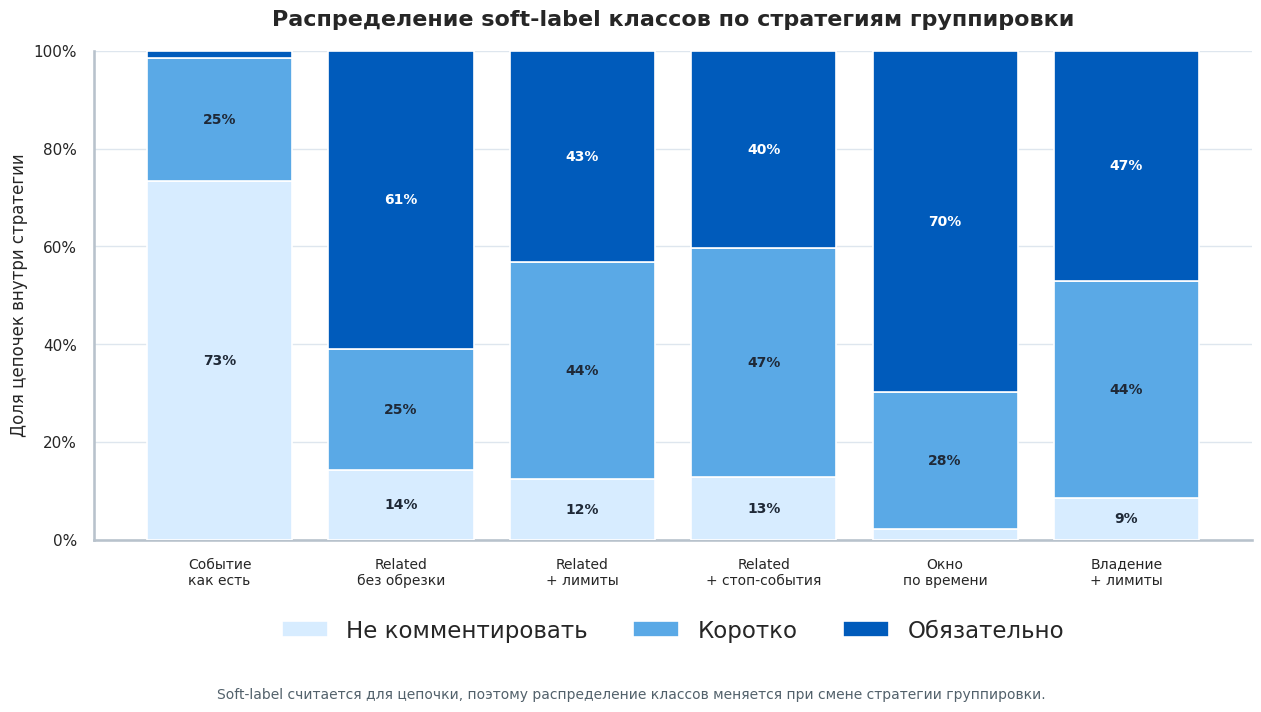

saved: /Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments/figures/soft_label_3_distribution_by_strategy.png

=== event_only ===
rows train/val/test: 108719 37556 41583
class distribution train: {0: 0.73, 1: 0.255, 2: 0.015}

=== related_only ===
rows train/val/test: 11368 3792 4101
class distribution train: {0: 0.146, 1: 0.247, 2: 0.606}

=== related_cap ===
rows train/val/test: 28740 9779 10781
class distribution train: {0: 0.127, 1: 0.438, 2: 0.435}

=== related_stop_cap ===
rows train/val/test: 30636 10349 11446
class distribution train: {0: 0.131, 1: 0.465, 2: 0.404}

=== time_window ===
rows train/val/test: 20057 6890 7652
class distribution train: {0: 0.023, 1: 0.272, 2: 0.705}

=== possession_cap ===
rows train/val/test: 27769 9369 10467
class distribution train: {0: 0.085, 1: 0.441, 2: 0.474}


,strategy,model,split,rows,matches,macro_f1,weighted_f1,balanced_accuracy,accuracy
5,event_only,CatBoost,test,41583,11,1.000000,1.000000,1.000000,1.000000
2,event_only,LogReg,test,41583,11,0.998867,0.999880,0.999839,0.999880
35,possession_cap,CatBoost,test,10467,11,0.998469,0.997898,0.998504,0.997898
32,possession_cap,LogReg,test,10467,11,0.997424,0.996465,0.997430,0.996465
17,related_cap,CatBoost,test,10781,11,0.999229,0.998980,0.999216,0.998980
14,related_cap,LogReg,test,10781,11,0.997961,0.997681,0.998249,0.997681
11,related_only,CatBoost,test,4101,11,0.992904,0.992920,0.991581,0.992929
8,related_only,LogReg,test,4101,11,0.981133,0.982025,0.984205,0.981956
23,related_stop_cap,CatBoost,test,11446,11,0.999399,0.999214,0.999365,0.999214
20,related_stop_cap,LogReg,test,11446,11,0.998084,0.997816,0.998383,0.997816


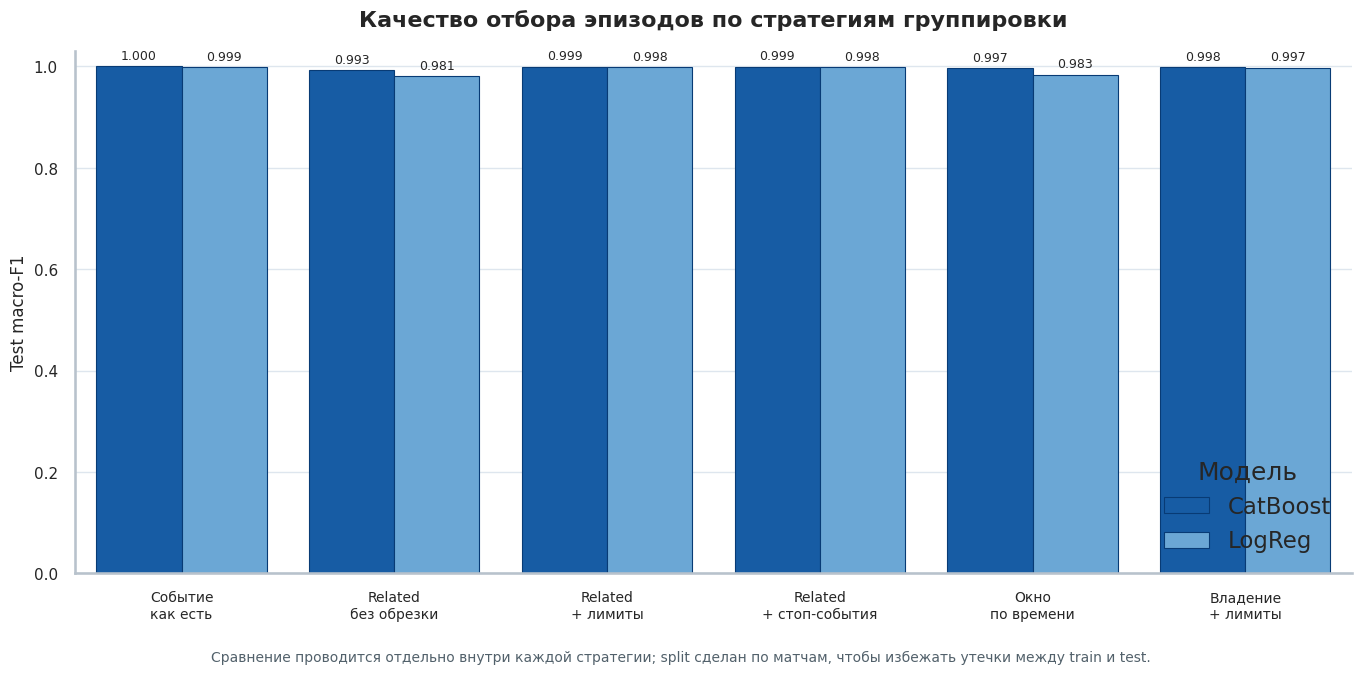

saved: /Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments/figures/model_macro_f1_by_strategy.png

=== pooled model ===
train/val/test: 227289 77735 86030
matches train/val/test: 30 10 11


,strategy,model,split,rows,matches,macro_f1,weighted_f1,balanced_accuracy,accuracy
0,pooled,LogReg,train,227289,30,0.999299,0.999366,0.999326,0.999366
1,pooled,LogReg,val,77735,10,0.998789,0.998919,0.998839,0.998919
2,pooled,LogReg,test,86030,11,0.999027,0.999117,0.999056,0.999117
3,pooled,CatBoost,train,227289,30,0.999906,0.999916,0.999903,0.999916
4,pooled,CatBoost,val,77735,10,0.999646,0.999691,0.999646,0.999691
5,pooled,CatBoost,test,86030,11,0.999683,0.999721,0.999665,0.999721


,pred_0,pred_1,pred_2
true_0,34895,0,0
true_1,0,28424,6
true_2,0,18,22687


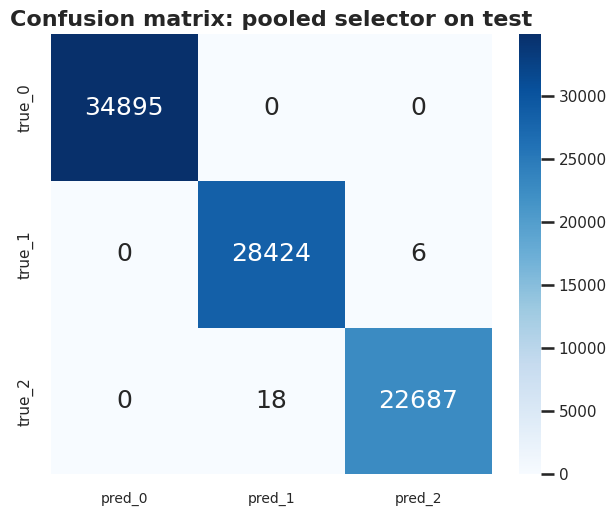

saved: /Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments/figures/confusion_matrix_pooled_test.png


In [112]:
feature_cols_num = [
    'events_n','duration_sec','high_event_n','set_play_n','long_pass_n',
    'entered_opp_half_n','entered_opp_box_n','left_own_box_n',
    'forward_moves_n','backward_moves_n','lateral_moves_n','progressive_carry_n',
    'switched_flank_n','bad_pass_outcome_n',
    'corner_zone_end_n','throwin_end_n','pre_box_end_n',
    'third_transition_n','ended_final_third_n','center_circle_touch_n',
    'mean_forward_delta','max_forward_delta','mean_abs_lateral_delta',
    'mean_gap_sec','max_gap_sec','low_signal_n',
] + [c for c in df_chains.columns if c.startswith('class_') and c.endswith('_n')]

feature_cols_cat = [
    'strategy','first_type','last_type','period','stage',
    'first_start_rel','last_end_rel','first_start_abs','last_end_abs',
    'dominant_lane','dominant_start_rel','dominant_end_rel','dominant_zone_transition',
]

# Оставляем только существующие колонки.
feature_cols_num = [c for c in feature_cols_num if c in df_chains.columns]
feature_cols_cat = [c for c in feature_cols_cat if c in df_chains.columns]
all_feature_cols = feature_cols_num + feature_cols_cat

work = df_chains.dropna(subset=[TARGET]).copy()
work['match_id'] = work['match_id'].astype(str)
for c in feature_cols_cat:
    work[c] = work[c].fillna('unknown').astype(str)

print('rows total:', len(work))
print('matches total:', work['match_id'].nunique())
print('features numeric:', len(feature_cols_num))
print('features categorical:', len(feature_cols_cat))

# --- 1) Class distribution by strategy ---
# Soft-label считается для цепочки, а цепочка зависит от стратегии,
# поэтому баланс классов смотрим отдельно по стратегиям.
label_map_3 = {
    0: 'skip',
    1: 'brief',
    2: 'must',
}
label_ru_3 = {
    'skip': 'Не комментировать',
    'brief': 'Коротко',
    'must': 'Обязательно',
}
strategy_order = [
    'event_only', 'related_only', 'related_cap',
    'related_stop_cap', 'time_window', 'possession_cap',
]
strategy_ru = {
    'event_only': 'Событие\nкак есть',
    'related_only': 'Related\nбез обрезки',
    'related_cap': 'Related\n+ лимиты',
    'related_stop_cap': 'Related\n+ стоп-события',
    'time_window': 'Окно\nпо времени',
    'possession_cap': 'Владение\n+ лимиты',
}

dist_by_strategy = (
    work
    .groupby(['strategy', TARGET])
    .size()
    .reset_index(name='n')
)
dist_by_strategy['share'] = dist_by_strategy['n'] / dist_by_strategy.groupby('strategy')['n'].transform('sum')
dist_by_strategy['class_label'] = dist_by_strategy[TARGET].map(label_map_3)
dist_by_strategy['class_ru'] = dist_by_strategy['class_label'].map(label_ru_3)
dist_by_strategy['strategy_ru'] = dist_by_strategy['strategy'].map(strategy_ru).fillna(dist_by_strategy['strategy'])

display(dist_by_strategy)
dist_by_strategy.to_csv(TAB_DIR / 'soft_label_3_distribution_by_strategy.csv', index=False)

pivot_share = (
    dist_by_strategy
    .pivot_table(index='strategy_ru', columns='class_ru', values='share', aggfunc='sum', fill_value=0, observed=False)
)
class_order_ru = ['Не комментировать', 'Коротко', 'Обязательно']
pivot_share = pivot_share.reindex(columns=class_order_ru, fill_value=0)
ordered_labels = [strategy_ru[s] for s in strategy_order if strategy_ru[s] in pivot_share.index]
pivot_share = pivot_share.reindex(ordered_labels)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.titlesize': 16,
    'xtick.labelsize': 10,
    'ytick.labelsize': 11,
})

fig, ax = plt.subplots(figsize=(12.5, 6.5), constrained_layout=True)
fig.patch.set_facecolor('white')
colors = {
    'Не комментировать': '#D7ECFF',
    'Коротко': '#5AA9E6',
    'Обязательно': '#005BBB',
}
bottom = np.zeros(len(pivot_share))
x = np.arange(len(pivot_share))
for cls in class_order_ru:
    vals = pivot_share[cls].to_numpy()
    ax.bar(
        x, vals, bottom=bottom, label=cls,
        color=colors[cls], edgecolor='white', linewidth=1.2, zorder=3,
    )
    for i, (v, btm) in enumerate(zip(vals, bottom)):
        if v >= 0.06:
            ax.text(
                i, btm + v / 2, f'{v * 100:.0f}%',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if cls == 'Обязательно' else '#1F2937',
            )
    bottom += vals

ax.set_title('Распределение soft-label классов по стратегиям группировки', pad=18)
ax.set_ylabel('Доля цепочек внутри стратегии')
ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(pivot_share.index)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda y, _: f'{y * 100:.0f}%')
ax.grid(axis='y', color='#D9E2EC', linewidth=1.0, alpha=0.85, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#B8C2CC')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.text(
    0.5, -0.05,
    'Soft-label считается для цепочки, поэтому распределение классов меняется при смене стратегии группировки.',
    ha='center', va='top', fontsize=10, color='#52616B',
)
out_path = FIG_DIR / 'soft_label_3_distribution_by_strategy.png'
fig.savefig(out_path, dpi=220, bbox_inches='tight', facecolor='white')
plt.show()
print('saved:', out_path)


# --- 2) Helpers: split, train, evaluate ---
def evaluate(y_true, y_pred):
    return {
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
    }


def split_by_match(df, test_size=TEST_SIZE, val_size=VAL_SIZE, random_state=RANDOM_STATE):
    """Split по match_id: один матч не должен быть одновременно в train и test."""
    df = df.copy()
    df['match_id'] = df['match_id'].astype(str)
    groups_n = df['match_id'].nunique()
    if groups_n < 5:
        raise ValueError(f'Need at least 5 matches for stable split, got {groups_n}')

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trainval_idx, test_idx = next(gss.split(df, groups=df['match_id']))
    trainval_df = df.iloc[trainval_idx].copy()
    test_df = df.iloc[test_idx].copy()

    val_rel = val_size / (1.0 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_rel, random_state=random_state + 1)
    train_idx, val_idx = next(gss2.split(trainval_df, groups=trainval_df['match_id']))
    train_df = trainval_df.iloc[train_idx].copy()
    val_df = trainval_df.iloc[val_idx].copy()
    return train_df, val_df, test_df


def train_logreg(train_df, feature_cols_num, feature_cols_cat):
    prep = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), feature_cols_num),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), feature_cols_cat),
    ])
    model = Pipeline([
        ('prep', prep),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ])
    model.fit(train_df[feature_cols_num + feature_cols_cat], train_df[TARGET])
    return model


def train_catboost(train_df, val_df, feature_cols_num, feature_cols_cat):
    if not HAS_CATBOOST:
        return None
    cat_idx = [len(feature_cols_num) + i for i in range(len(feature_cols_cat))]
    Xtr = train_df[feature_cols_num + feature_cols_cat].copy()
    Xva = val_df[feature_cols_num + feature_cols_cat].copy()
    for c in feature_cols_cat:
        Xtr[c] = Xtr[c].fillna('unknown').astype(str)
        Xva[c] = Xva[c].fillna('unknown').astype(str)
    model = CatBoostClassifier(
        loss_function='MultiClass', eval_metric='TotalF1', random_seed=RANDOM_STATE,
        depth=8, learning_rate=0.06, iterations=600, verbose=False,
    )
    model.fit(Xtr, train_df[TARGET], cat_features=cat_idx, eval_set=(Xva, val_df[TARGET]), use_best_model=True)
    return model


def eval_model_on_splits(model, model_name, train_df, val_df, test_df, feature_cols_num, feature_cols_cat, strategy='pooled'):
    rows = []
    for split_name, sdf in [('train', train_df), ('val', val_df), ('test', test_df)]:
        Xs = sdf[feature_cols_num + feature_cols_cat].copy()
        for c in feature_cols_cat:
            Xs[c] = Xs[c].fillna('unknown').astype(str)
        pred = np.array(model.predict(Xs)).reshape(-1).astype(int)
        rows.append({
            'strategy': strategy,
            'model': model_name,
            'split': split_name,
            'rows': len(sdf),
            'matches': sdf['match_id'].nunique(),
            **evaluate(sdf[TARGET], pred),
        })
    return rows


# --- 3) Главное сравнение: модели отдельно для каждой стратегии ---
leader_by_strategy_rows = []
models_by_strategy = {}

for strategy in strategy_order:
    sdf = work[work['strategy'] == strategy].copy()
    if sdf.empty:
        continue

    # Если вдруг стратегия дала только один класс, классификатор не обучится корректно.
    if sdf[TARGET].nunique() < 2:
        print('skip strategy with one class:', strategy)
        continue

    train_s, val_s, test_s = split_by_match(sdf)
    print('\n===', strategy, '===')
    print('rows train/val/test:', len(train_s), len(val_s), len(test_s))
    print('class distribution train:', train_s[TARGET].value_counts(normalize=True).sort_index().round(3).to_dict())

    lr_s = train_logreg(train_s, feature_cols_num, feature_cols_cat)
    leader_by_strategy_rows.extend(
        eval_model_on_splits(lr_s, 'LogReg', train_s, val_s, test_s, feature_cols_num, feature_cols_cat, strategy=strategy)
    )
    models_by_strategy[(strategy, 'LogReg')] = lr_s

    cb_s = train_catboost(train_s, val_s, feature_cols_num, feature_cols_cat)
    if cb_s is not None:
        leader_by_strategy_rows.extend(
            eval_model_on_splits(cb_s, 'CatBoost', train_s, val_s, test_s, feature_cols_num, feature_cols_cat, strategy=strategy)
        )
        models_by_strategy[(strategy, 'CatBoost')] = cb_s

leaderboard_by_strategy_df = pd.DataFrame(leader_by_strategy_rows)
display(leaderboard_by_strategy_df.sort_values(['split', 'strategy', 'model']))
leaderboard_by_strategy_df.to_csv(TAB_DIR / 'leaderboard_by_strategy.csv', index=False)

# Презентабельный график: test macro-F1 по стратегиям.
plot_lb = leaderboard_by_strategy_df[leaderboard_by_strategy_df['split'] == 'test'].copy()
plot_lb['strategy_ru'] = plot_lb['strategy'].map(strategy_ru).fillna(plot_lb['strategy'])
plot_lb['strategy_ru'] = pd.Categorical(plot_lb['strategy_ru'], categories=ordered_labels, ordered=True)
plot_lb = plot_lb.sort_values(['strategy_ru', 'model'])

fig, ax = plt.subplots(figsize=(13.5, 6.2), constrained_layout=True)
fig.patch.set_facecolor('white')
sns.barplot(
    data=plot_lb,
    x='strategy_ru', y='macro_f1', hue='model',
    palette={'LogReg': '#5AA9E6', 'CatBoost': '#005BBB'},
    edgecolor='#083B75', linewidth=0.8, ax=ax,
)
ax.set_title('Качество отбора эпизодов по стратегиям группировки', pad=18)
ax.set_xlabel('')
ax.set_ylabel('Test macro-F1')
ax.set_ylim(0, 1.03)
ax.grid(axis='y', color='#D9E2EC', linewidth=1.0, alpha=0.85, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#B8C2CC')
ax.legend(frameon=False, title='Модель', loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

fig.text(
    0.5, -0.04,
    'Сравнение проводится отдельно внутри каждой стратегии; split сделан по матчам, чтобы избежать утечки между train и test.',
    ha='center', va='top', fontsize=10, color='#52616B',
)
out_path = FIG_DIR / 'model_macro_f1_by_strategy.png'
fig.savefig(out_path, dpi=220, bbox_inches='tight', facecolor='white')
plt.show()
print('saved:', out_path)


# --- 4) Pooled-модель для последующих блоков feature importance / SHAP ---
# Эта модель обучается на всех стратегиях сразу. Она нужна для интерпретации признаков,
# но не заменяет сравнение leaderboard_by_strategy_df.
train_df, val_df, test_df = split_by_match(work)
print('\n=== pooled model ===')
print('train/val/test:', len(train_df), len(val_df), len(test_df))
print('matches train/val/test:', train_df['match_id'].nunique(), val_df['match_id'].nunique(), test_df['match_id'].nunique())

leader_rows = []
logreg = train_logreg(train_df, feature_cols_num, feature_cols_cat)
leader_rows.extend(eval_model_on_splits(logreg, 'LogReg', train_df, val_df, test_df, feature_cols_num, feature_cols_cat, strategy='pooled'))

cb = None
if HAS_CATBOOST:
    cb = train_catboost(train_df, val_df, feature_cols_num, feature_cols_cat)
    leader_rows.extend(eval_model_on_splits(cb, 'CatBoost', train_df, val_df, test_df, feature_cols_num, feature_cols_cat, strategy='pooled'))

if RUN_TABNET and HAS_TABNET:
    # TabNet опционален: он тяжелее, требует числовой матрицы после one-hot.
    # Для ВКР достаточно запускать его как дополнительный baseline, если есть время/ресурсы.
    print('TabNet block is intentionally optional here. Set RUN_TABNET=True and add encoded matrix if needed.')

leaderboard_df = pd.DataFrame(leader_rows)
display(leaderboard_df)
leaderboard_df.to_csv(TAB_DIR / 'leaderboard_models_pooled.csv', index=False)

# Confusion matrix для pooled CatBoost или LogReg на test.
main_model = cb if cb is not None else logreg
X_test_main = test_df[feature_cols_num + feature_cols_cat].copy()
for c in feature_cols_cat:
    X_test_main[c] = X_test_main[c].fillna('unknown').astype(str)
pred_test = np.array(main_model.predict(X_test_main)).reshape(-1).astype(int)
cm = confusion_matrix(test_df[TARGET], pred_test, labels=sorted(work[TARGET].unique()))
cm_df = pd.DataFrame(cm, index=[f'true_{x}' for x in sorted(work[TARGET].unique())], columns=[f'pred_{x}' for x in sorted(work[TARGET].unique())])
display(cm_df)
cm_df.to_csv(TAB_DIR / 'confusion_matrix_pooled_test.csv')

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix: pooled selector on test')
plt.tight_layout()
out_path = FIG_DIR / 'confusion_matrix_pooled_test.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()
print('saved:', out_path)


In [113]:
# --- Honest comparison by strategy: full vs no direct rule features ---
# Проверяем, не выигрывает ли модель только потому, что ей дали признаки,
# из которых напрямую была собрана формула soft-label.

DIRECT_RULE_FEATURES = {
    # Прямые положительные компоненты score:
    'class_shot_n',
    'entered_opp_box_n',
    'high_event_n',
    'long_pass_n',
    'forward_moves_n',
    'switched_flank_n',
    'bad_pass_outcome_n',
    'set_play_n',

    # Прямой отрицательный компонент:
    'low_signal_n',

    # Признаки, участвующие в штрафах:
    'events_n',
    'duration_sec',
}

feature_sets_by_name = {
    'full': {
        'num': feature_cols_num,
        'cat': feature_cols_cat,
    },
    'no_direct_rule_features': {
        'num': [c for c in feature_cols_num if c not in DIRECT_RULE_FEATURES],
        'cat': feature_cols_cat,
    },
}

honest_rows = []

for strategy in strategy_order:
    sdf = work[work['strategy'] == strategy].copy()
    if sdf.empty or sdf[TARGET].nunique() < 2:
        continue

    train_s, val_s, test_s = split_by_match(sdf)

    for feature_set_name, fs in feature_sets_by_name.items():
        num_cols = fs['num']
        cat_cols = fs['cat']

        print(
            f'\n=== strategy={strategy} | feature_set={feature_set_name} '
            f'| num={len(num_cols)} cat={len(cat_cols)} ==='
        )

        # LogReg
        lr_s = train_logreg(train_s, num_cols, cat_cols)
        honest_rows.extend([
            {
                **row,
                'feature_set': feature_set_name,
            }
            for row in eval_model_on_splits(
                lr_s,
                'LogReg',
                train_s,
                val_s,
                test_s,
                num_cols,
                cat_cols,
                strategy=strategy,
            )
        ])

        # CatBoost
        cb_s = train_catboost(train_s, val_s, num_cols, cat_cols)
        if cb_s is not None:
            honest_rows.extend([
                {
                    **row,
                    'feature_set': feature_set_name,
                }
                for row in eval_model_on_splits(
                    cb_s,
                    'CatBoost',
                    train_s,
                    val_s,
                    test_s,
                    num_cols,
                    cat_cols,
                    strategy=strategy,
                )
            ])

honest_by_strategy_df = pd.DataFrame(honest_rows)

display(
    honest_by_strategy_df
    .sort_values(['strategy', 'feature_set', 'model', 'split'])
)

honest_by_strategy_df.to_csv(
    TAB_DIR / 'honest_feature_set_by_strategy.csv',
    index=False,
)



=== strategy=event_only | feature_set=full | num=35 cat=13 ===

=== strategy=event_only | feature_set=no_direct_rule_features | num=24 cat=13 ===

=== strategy=related_only | feature_set=full | num=35 cat=13 ===

=== strategy=related_only | feature_set=no_direct_rule_features | num=24 cat=13 ===

=== strategy=related_cap | feature_set=full | num=35 cat=13 ===

=== strategy=related_cap | feature_set=no_direct_rule_features | num=24 cat=13 ===

=== strategy=related_stop_cap | feature_set=full | num=35 cat=13 ===

=== strategy=related_stop_cap | feature_set=no_direct_rule_features | num=24 cat=13 ===

=== strategy=time_window | feature_set=full | num=35 cat=13 ===

=== strategy=time_window | feature_set=no_direct_rule_features | num=24 cat=13 ===

=== strategy=possession_cap | feature_set=full | num=35 cat=13 ===

=== strategy=possession_cap | feature_set=no_direct_rule_features | num=24 cat=13 ===


,strategy,model,split,rows,matches,macro_f1,weighted_f1,balanced_accuracy,accuracy,feature_set
5,event_only,CatBoost,test,41583,11,1.000000,1.000000,1.000000,1.000000,full
3,event_only,CatBoost,train,108719,30,1.000000,1.000000,1.000000,1.000000,full
4,event_only,CatBoost,val,37556,10,1.000000,1.000000,1.000000,1.000000,full
2,event_only,LogReg,test,41583,11,0.998867,0.999880,0.999839,0.999880,full
0,event_only,LogReg,train,108719,30,0.999453,0.999954,0.999940,0.999954,full
...,...,...,...,...,...,...,...,...,...,...
57,time_window,CatBoost,train,20057,30,0.794162,0.802781,0.774354,0.819664,no_direct_rule_features
58,time_window,CatBoost,val,6890,10,0.731434,0.724737,0.710165,0.752685,no_direct_rule_features
56,time_window,LogReg,test,7652,11,0.692969,0.712929,0.792668,0.698641,no_direct_rule_features
54,time_window,LogReg,train,20057,30,0.719962,0.719052,0.816702,0.703694,no_direct_rule_features


In [114]:
TAB_DIR 

PosixPath('/Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments/tables')

## Model input diagnostics: что именно передаётся в LogReg/CatBoost/TabNet

После ячейки обучения появляются:

- `feature_cols_num` — числовые признаки;
- `feature_cols_cat` — категориальные признаки;
- `train_df`, `val_df`, `test_df` — разбиение по матчам;
- `TARGET = 'soft_label_3'` — целевая переменная.

Эта ячейка показывает:

- какие колонки реально идут в модель;
- размер train/val/test;
- распределение классов в каждом split;
- пример `X_train` и `y_train`.


In [ ]:
# --- MODEL INPUT DIAGNOSTICS ---

print('TARGET:', TARGET)
print('numeric features:', len(feature_cols_num))
print(feature_cols_num)

print()
print('categorical features:', len(feature_cols_cat))
print(feature_cols_cat)

model_input_cols = feature_cols_num + feature_cols_cat
print()
print('X columns total:', len(model_input_cols))

print()
print('Train/val/test shapes:')
print('train:', train_df.shape)
print('val  :', val_df.shape)
print('test :', test_df.shape)

print()
print('Class distribution by split:')
for split_name, sdf in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(split_name, sdf[TARGET].value_counts(normalize=False).sort_index().to_dict(), 'matches:', sdf['match_id'].nunique())

print()
print('X_train preview:')
display(train_df[model_input_cols].head(10))

print()
print('y_train preview:')
display(train_df[[TARGET, 'soft_label_5', 'strategy', 'match_id']].head(10))

print()
print('Rows where class is must (soft_label_3=2):')
must_cols = ['strategy', 'match_id', 'events_n', 'duration_sec', 'first_type', 'last_type', 'entered_opp_box_n', 'class_shot_n', 'soft_label_5', 'soft_label_3']
must_cols = [c for c in must_cols if c in train_df.columns]
display(train_df.loc[train_df[TARGET] == 2, must_cols].head(20))


## Honest feature-set check: проверяем, не учится ли модель просто копировать формулу

Высокие `macro-F1` около 0.99 ожидаемы, если модель получает признаки, из которых прямо собран `soft_label`.

Чтобы проверить честнее, сравниваем несколько наборов признаков:

1. **full** — все признаки.
2. **no_exact_score_terms** — убираем прямые компоненты формулы score: `class_shot_n`, `entered_opp_box_n`, `high_event_n`, `long_pass_n`, `forward_moves_n`, `switched_flank_n`, `bad_pass_outcome_n`, `set_play_n`, `low_signal_n`, а также `events_n` и `duration_sec`, которые входят в штрафы.
3. **structure_zone_only** — оставляем в основном структуру, зоны, движение и типы начала/конца. Это всё ещё не gold-оценка, но уже меньше похоже на прямое восстановление формулы.

Если full сильно лучше reduced-наборов, значит модель действительно воспроизводит эвристику по её прямым компонентам. Это честно и нормально для proxy-разметки, но в ВКР надо так и писать.


In [ ]:
# --- HONEST FEATURE SET CHECK ---

RULE_CORE_FEATURES = {
    'class_shot_n', 'entered_opp_box_n', 'high_event_n', 'long_pass_n',
    'forward_moves_n', 'switched_flank_n', 'bad_pass_outcome_n',
    'set_play_n', 'low_signal_n',
    'events_n', 'duration_sec',
}

STRUCTURE_ZONE_NUM = [
    'mean_forward_delta', 'max_forward_delta', 'mean_abs_lateral_delta',
    'mean_gap_sec', 'max_gap_sec', 'backward_moves_n', 'lateral_moves_n',
    'progressive_carry_n', 'corner_zone_end_n', 'throwin_end_n', 'pre_box_end_n',
    'center_circle_touch_n',
]
STRUCTURE_ZONE_CAT = [
    'strategy', 'first_type', 'last_type', 'period', 'stage',
    'first_start_rel', 'last_end_rel', 'first_start_abs', 'last_end_abs',
    'dominant_lane', 'dominant_start_rel', 'dominant_end_rel', 'dominant_zone_transition',
]

FEATURE_SET_SPECS = {
    'full': {
        'num': feature_cols_num,
        'cat': feature_cols_cat,
    },
    'no_exact_score_terms': {
        'num': [c for c in feature_cols_num if c not in RULE_CORE_FEATURES],
        'cat': feature_cols_cat,
    },
    'structure_zone_only': {
        'num': [c for c in STRUCTURE_ZONE_NUM if c in feature_cols_num],
        'cat': [c for c in STRUCTURE_ZONE_CAT if c in feature_cols_cat],
    },
}


def fit_eval_logreg_feature_set(name, num_cols, cat_cols):
    prep_local = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ])
    model = Pipeline([
        ('prep', prep_local),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ])
    cols = num_cols + cat_cols
    model.fit(train_df[cols], train_df[TARGET])
    rows = []
    for split_name, sdf in [('val', val_df), ('test', test_df)]:
        pred = model.predict(sdf[cols])
        rows.append({'feature_set': name, 'model': 'LogReg', 'split': split_name, **evaluate(sdf[TARGET], pred)})
    return rows


def fit_eval_catboost_feature_set(name, num_cols, cat_cols):
    if not HAS_CATBOOST:
        return []
    cols = num_cols + cat_cols
    Xtr = train_df[cols].copy()
    Xva = val_df[cols].copy()
    Xte = test_df[cols].copy()
    for c in cat_cols:
        Xtr[c] = Xtr[c].fillna('unknown').astype(str)
        Xva[c] = Xva[c].fillna('unknown').astype(str)
        Xte[c] = Xte[c].fillna('unknown').astype(str)
    model = CatBoostClassifier(
        loss_function='MultiClass', eval_metric='TotalF1', random_seed=RANDOM_STATE,
        depth=8, learning_rate=0.06, iterations=400, verbose=False
    )
    model.fit(Xtr, train_df[TARGET], cat_features=[len(num_cols)+i for i in range(len(cat_cols))], eval_set=(Xva, val_df[TARGET]), use_best_model=True)
    rows = []
    for split_name, Xs, ys in [('val', Xva, val_df[TARGET]), ('test', Xte, test_df[TARGET])]:
        pred = np.array(model.predict(Xs)).reshape(-1).astype(int)
        rows.append({'feature_set': name, 'model': 'CatBoost', 'split': split_name, **evaluate(ys, pred)})
    return rows

honest_rows = []
for name, spec in FEATURE_SET_SPECS.items():
    num_cols = spec['num']
    cat_cols = spec['cat']
    print(name, 'num:', len(num_cols), 'cat:', len(cat_cols))
    honest_rows += fit_eval_logreg_feature_set(name, num_cols, cat_cols)
    honest_rows += fit_eval_catboost_feature_set(name, num_cols, cat_cols)

honest_feature_eval_df = pd.DataFrame(honest_rows)
display(honest_feature_eval_df.sort_values(['split', 'feature_set', 'model']))
honest_feature_eval_df.to_csv(TAB_DIR / 'honest_feature_set_eval.csv', index=False)


## Feature importance, reduced features, PCA и SHAP

Этот блок нужен для интерпретируемости и возможного уменьшения числа признаков.

Логика:

1. смотрим важность признаков CatBoost;
2. выбираем top-N признаков + обязательные футбольные признаки;
3. обучаем reduced-модель;
4. сравниваем full и reduced;
5. PCA используем как визуализацию признакового пространства;
6. SHAP оставляем опционально, потому что он может быть тяжёлым.


In [ ]:
IMPORTANCE_TOP_N = 30
MANDATORY_KEEP = {
    'strategy','events_n','duration_sec','high_event_n','long_pass_n',
    'entered_opp_half_n','entered_opp_box_n','class_shot_n','class_transition_n',
    'first_type','last_type','period','first_start_rel','last_end_rel','dominant_zone_transition'
}

importance_df = pd.DataFrame()
if HAS_CATBOOST and 'cb' in globals():
    all_features = feature_cols_num + feature_cols_cat
    importance_df = pd.DataFrame({
        'feature': all_features,
        'importance': cb.get_feature_importance(),
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    display(importance_df.head(50))
    importance_df.to_csv(TAB_DIR / 'catboost_feature_importance.csv', index=False)

    plt.figure(figsize=(10, 9))
    sns.barplot(data=importance_df.head(30), y='feature', x='importance', color='#008ED6')
    plt.title('CatBoost feature importance: top-30')
    plt.tight_layout()
    plt.show()

    keep = sorted((set(importance_df.head(IMPORTANCE_TOP_N)['feature']) | MANDATORY_KEEP) & set(all_features))
    reduced_num = [c for c in feature_cols_num if c in keep]
    reduced_cat = [c for c in feature_cols_cat if c in keep]
    print('full:', len(all_features), 'reduced:', len(reduced_num) + len(reduced_cat))

    Xtr = train_df[reduced_num + reduced_cat].copy()
    Xva = val_df[reduced_num + reduced_cat].copy()
    Xte = test_df[reduced_num + reduced_cat].copy()
    for c in reduced_cat:
        Xtr[c] = Xtr[c].fillna('unknown').astype(str)
        Xva[c] = Xva[c].fillna('unknown').astype(str)
        Xte[c] = Xte[c].fillna('unknown').astype(str)
    cb_reduced = CatBoostClassifier(
        loss_function='MultiClass', eval_metric='TotalF1', random_seed=RANDOM_STATE,
        depth=8, learning_rate=0.06, iterations=600, verbose=False
    )
    cb_reduced.fit(Xtr, train_df[TARGET], cat_features=[len(reduced_num)+i for i in range(len(reduced_cat))], eval_set=(Xva, val_df[TARGET]), use_best_model=True)
    red_rows=[]
    for split_name, Xs, ys in [('val', Xva, val_df[TARGET]), ('test', Xte, test_df[TARGET])]:
        pred = np.array(cb_reduced.predict(Xs)).reshape(-1).astype(int)
        red_rows.append({'model':'CatBoostReduced','split':split_name, **evaluate(ys, pred)})
    reduced_df = pd.DataFrame(red_rows)
    display(reduced_df)
    reduced_df.to_csv(TAB_DIR / 'reduced_model_leaderboard.csv', index=False)

# PCA-картинка по числовым признакам.
X_num = train_df[feature_cols_num].copy()
X_num = SimpleImputer(strategy='median').fit_transform(X_num)
X_num = StandardScaler().fit_transform(X_num)
emb = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_num)
pca_df = pd.DataFrame({'pc1': emb[:,0], 'pc2': emb[:,1], TARGET: train_df[TARGET].astype(str).values})
plt.figure(figsize=(9, 7))
sns.scatterplot(data=pca_df.sample(min(5000, len(pca_df)), random_state=RANDOM_STATE), x='pc1', y='pc2', hue=TARGET, palette='Blues')
plt.title('PCA projection of chain features')
plt.tight_layout()
plt.show()

if RUN_SHAP and HAS_CATBOOST and 'cb' in globals():
    import shap
    # Для большого набора это может быть долго; запускай на небольшой подвыборке.
    print('SHAP block placeholder: run manually on sampled Pool if needed')


## Ранжирование эпизодов внутри матча

Классификация отвечает на вопрос: `skip / brief / must`.

Ранжирование отвечает на другой вопрос: какие эпизоды внутри матча поставить выше, если есть ограниченный бюджет комментариев или LLM-токенов.

Релевантность берём из `soft_label_5`. Метрики:

- `NDCG@K`;
- `Precision@K`;
- `Recall@K`.


In [ ]:
def dcg_at_k(relevance, k):
    rel = np.asarray(relevance, dtype=float)[:k]
    if len(rel) == 0:
        return 0.0
    return float(np.sum((2**rel - 1) / np.log2(np.arange(len(rel)) + 2)))


def ndcg_at_k(y_true, y_score, k):
    y_true = np.asarray(y_true)
    order = np.argsort(-np.asarray(y_score))
    ideal = np.argsort(-y_true)
    dcg = dcg_at_k(y_true[order], k)
    idcg = dcg_at_k(y_true[ideal], k)
    return 0.0 if idcg == 0 else dcg / idcg


def precision_recall_at_k(y_binary, y_score, k):
    y = np.asarray(y_binary).astype(int)
    order = np.argsort(-np.asarray(y_score))[:min(k, len(y))]
    hits = int(y[order].sum())
    return hits / max(len(order), 1), hits / max(int(y.sum()), 1)


def evaluate_ranking(df, score_col, k_list=[10,25,50,100]):
    rows=[]
    for k in k_list:
        ndcgs, ps, rs = [], [], []
        for mid, g in df.groupby('match_id'):
            y_rel = g['soft_label_5'].astype(float).values
            y_imp = (g['soft_label_3'].astype(int).values >= 1).astype(int)
            score = g[score_col].astype(float).values
            ndcgs.append(ndcg_at_k(y_rel, score, k))
            p, r = precision_recall_at_k(y_imp, score, k)
            ps.append(p); rs.append(r)
        rows.append({'score': score_col, 'k': k, 'ndcg_at_k': np.mean(ndcgs), 'precision_at_k': np.mean(ps), 'recall_at_k': np.mean(rs)})
    return rows

rank_rows=[]
test_rank = test_df.copy()
test_rank['score_rule'] = test_rank['soft_label_5'].astype(float)
rank_rows += [{'model':'RuleSoftLabel', **r} for r in evaluate_ranking(test_rank, 'score_rule')]

if 'logreg' in globals():
    proba = logreg.predict_proba(test_df[feature_cols_num + feature_cols_cat])
    cls = list(logreg.named_steps['clf'].classes_)
    score = np.zeros(len(test_df))
    for weight, label in [(1.0, 1), (2.0, 2)]:
        if label in cls:
            score += weight * proba[:, cls.index(label)]
    test_lr = test_df.copy()
    test_lr['score_logreg'] = score
    rank_rows += [{'model':'LogRegProbability', **r} for r in evaluate_ranking(test_lr, 'score_logreg')]

ranking_df = pd.DataFrame(rank_rows)
display(ranking_df)
ranking_df.to_csv(TAB_DIR / 'ranking_metrics.csv', index=False)


## Что отправляем в LLM

Для LLM отправляем не таблицу признаков, а JSON-payload эпизода.

В payload должны быть:

- события цепочки;
- очищенный `event_json`;
- `derived.orientation`, `derived.zones`, `derived.movement`, `derived.episode_signals`;
- сжатый `sb360_summary` или полный `sb360_json`;
- `chain_features`;
- метаданные матча.

Важно: модели отбора обучаются на всех 51 матчах, но финальный дорогой LLM/TTS-прогон ограничиваем списком `FINAL_LLM_MATCH_IDS`. Так мы используем все данные для устойчивых признаков и при этом не сжигаем токены на весь турнир.

Отправляем только цепочки с `soft_label_3 >= 1`, чтобы не тратить токены на низкосигнальные эпизоды.


In [ ]:
SB360_MODE = 'summary'  # none / summary / full
LLM_STRATEGY = 'related_stop_cap'
LLM_MATCH_IDS = FINAL_LLM_MATCH_IDS  # финальный прогон: только обязательный speak-набор


def summarize_360(sb):
    if not sb:
        return None
    ff = sb.get('freeze_frame') or []
    va = sb.get('visible_area') or []
    return {
        'freeze_frame_n': len(ff),
        'teammates_n': sum(1 for r in ff if r.get('teammate') is True),
        'opponents_n': sum(1 for r in ff if r.get('teammate') is False),
        'keepers_n': sum(1 for r in ff if r.get('keeper') is True),
        'visible_area_points_n': int(len(va)/2) if isinstance(va, list) else 0,
    }


def compact_payload_for_llm(payload, sb360_mode='summary'):
    events=[]
    for item in payload.get('events', []):
        out = {'event_json': item.get('event_json'), 'derived': item.get('derived')}
        if sb360_mode == 'summary':
            out['sb360_summary'] = summarize_360(item.get('sb360_json'))
        elif sb360_mode == 'full':
            out['sb360_json'] = item.get('sb360_json')
        else:
            out['sb360_json'] = None
        events.append(out)
    return {
        'match_id': payload.get('match_id'),
        'strategy': payload.get('strategy'),
        'chain_event_ids': payload.get('chain_event_ids'),
        'chain_features': payload.get('chain_features'),
        'events': events,
    }

strategy_payloads_all = payloads_by_strategy[LLM_STRATEGY]
strategy_payloads = [p for p in strategy_payloads_all if str(p.get('match_id')) in set(LLM_MATCH_IDS)]

llm_payloads = []
for p in strategy_payloads:
    # Для финального прогона берём только эпизоды, которым эвристика дала ненулевую важность.
    # Более строгий вариант ниже в LLM-eval блоке использует soft_label_3.
    if (p.get('chain_features') or {}).get('importance_score_rule', 0) > 0:
        llm_payloads.append(compact_payload_for_llm(p, SB360_MODE))

out_json = OUT_DIR / f'llm_payloads_speak_set_{LLM_STRATEGY}_{SB360_MODE}.json'
out_json.write_text(json.dumps(llm_payloads, ensure_ascii=False, indent=2), encoding='utf-8')
print('all strategy payloads:', len(strategy_payloads_all))
print('speak_set strategy payloads:', len(strategy_payloads))
print('speak_set llm_payloads:', len(llm_payloads), 'saved:', out_json)
if llm_payloads:
    print(json.dumps(llm_payloads[0], ensure_ascii=False, indent=2)[:4000])


## Системный промпт LLM

Этот промпт должен быть одинаковым для всех моделей, если мы сравниваем LLM между собой.

Ожидаем JSON с текстом комментария и списком событий, которые модель реально прокомментировала. Это нужно для автоматической проверки.


In [ ]:
SYSTEM_PROMPT_COMMENTATOR = """Ты — тифлокомментатор футбольного матча для незрячего слушателя.
Отвечай всегда на русском языке.

Тебе передаётся один футбольный эпизод в JSON. Опиши, что происходит сейчас: где мяч, кто выполняет ключевое действие, чем эпизод заканчивается.

Правила стиля:
- настоящее время;
- без слов "затем", "потом", "после этого";
- не используй "мы", "они", "наши";
- называй игроков по фамилии из player.name;
- не перечисляй все события подряд;
- обычный эпизод: 1–2 предложения;
- насыщенный эпизод: до 3–5 коротких предложений;
- только факты из JSON, без догадок.

Используй derived-поля:
- orientation: куда атакует команда;
- zones: своя/чужая половина, штрафная, фланг;
- movement: вперёд/назад/поперёк относительно команды с мячом;
- episode_signals: длинный пас, вход в штрафную, смена фланга.

Верни строго JSON:
{
  "t_start": "...",
  "t_end": "...",
  "commentary": "...",
  "commented_event_ids": ["..."],
  "commented_event_types": ["Pass", "Shot"],
  "commentary_kind": "brief|must|heartbeat"
}
"""


def make_llm_user_prompt(payload):
    return 'ВХОДНОЙ EPISODE JSON:\n' + json.dumps(payload, ensure_ascii=False)

print(SYSTEM_PROMPT_COMMENTATOR[:1500])


## Оценка LLM-комментариев

Оценка не должна быть слишком тяжёлой. Достаточно трёх уровней:

1. Формат: валидный JSON, обязательные поля, время.
2. Самосогласованность: указанные `commented_event_ids` и `commented_event_types` реально есть во входе.
3. Смысловая оценка: LLM-as-a-judge + ручная проверка небольшой подвыборки.

Для аудио дополнительно считаем примерную длительность комментария по числу слов.


In [ ]:
def safe_extract_json(text):
    if isinstance(text, dict):
        return text
    try:
        return json.loads(str(text).strip())
    except Exception:
        pass
    m = re.search(r'\{.*\}', str(text), flags=re.S)
    if not m:
        return {}
    try:
        return json.loads(m.group(0))
    except Exception:
        return {}


def word_count_ru(text):
    return len(re.findall(r'[A-Za-zА-Яа-яЁё]+', text or ''))


def estimate_tts_sec(text, wpm=184.0):
    return round(word_count_ru(text) / wpm * 60.0, 2)


def payload_event_sets(payload):
    ids, types = set(), set()
    for item in payload.get('events', []):
        ej = item.get('event_json') or {}
        if ej.get('id'):
            ids.add(ej.get('id'))
        t = event_type(ej)
        if t:
            types.add(t)
    return ids, types


def evaluate_llm_output(payload, parsed):
    events = payload.get('events') or []
    t0 = ((events[0].get('event_json') or {}).get('timestamp')) if events else ''
    t1 = ((events[-1].get('event_json') or {}).get('timestamp')) if events else ''
    ids, types = payload_event_sets(payload)
    text = str(parsed.get('commentary') or '') if isinstance(parsed, dict) else ''
    out_ids = parsed.get('commented_event_ids', []) if isinstance(parsed, dict) else []
    out_types = parsed.get('commented_event_types', []) if isinstance(parsed, dict) else []
    out_ids = out_ids if isinstance(out_ids, list) else []
    out_types = out_types if isinstance(out_types, list) else []
    low = text.lower()
    return {
        'json_valid': int(isinstance(parsed, dict) and bool(parsed)),
        'required_fields': int(isinstance(parsed, dict) and all(k in parsed for k in ['t_start','t_end','commentary'])),
        'time_bounds_match': int(str(parsed.get('t_start')) == str(t0) and str(parsed.get('t_end')) == str(t1)) if isinstance(parsed, dict) else 0,
        'commentary_nonempty': int(bool(text.strip())),
        'commented_ids_valid': int(bool(out_ids) and all(x in ids for x in out_ids)),
        'commented_types_valid': int(bool(out_types) and all(x in types for x in out_types)),
        'no_forbidden_temporal': int(not any(w in low for w in ['затем','потом','после этого','далее'])),
        'word_count': word_count_ru(text),
        'est_tts_sec': estimate_tts_sec(text),
    }

JUDGE_PROMPT = """Ты оцениваешь тифлокомментарий по входному JSON эпизода.
Верни JSON: {"faithfulness":1-5,"saliency":1-5,"naturalness":1-5,"hallucination_risk":"low|medium|high","short_reason":"..."}.
Оцени только проверяемость по входным данным, выбор главного действия и естественность русского комментария.
"""


## LLM evaluation of grouping strategies

Этот блок отвечает на вопрос: **какая стратегия группировки реально лучше комментируется LLM**.

CatBoost/LogReg показывают, насколько удобно предсказывать soft-labels. Но этого недостаточно: стратегия может хорошо классифицироваться, но давать плохой вход для генерации текста.

Поэтому здесь мы делаем отдельный LLM-замер на фиксированной подвыборке:

1. Для каждой стратегии выбираем одинаковое число payload.
2. По умолчанию берём только `FINAL_LLM_MATCH_IDS`, потому что именно этот speak-набор потом будет озвучиваться.
3. Берём только эпизоды `soft_label_3 >= 1`, то есть потенциально достойные комментария.
4. Используем один и тот же `SYSTEM_PROMPT_COMMENTATOR`.
5. Сохраняем raw/parsed ответы.
6. Считаем автоматические метрики: JSON, времена, ids/types, длина, TTS-время.
7. Опционально запускаем LLM-as-a-judge.

API по умолчанию выключен. Чтобы запустить, поставь:

```python
RUN_GROUPING_LLM_API = True
```

Для первого прогона лучше оставить маленький `N_LLM_EVAL_PER_STRATEGY`, например 10--20.


In [ ]:
# --- LLM evaluation of grouping strategies ---

RUN_GROUPING_LLM_API = False
RUN_GROUPING_JUDGE_API = False
FORCE_GROUPING_LLM_API = False
CACHE_GROUPING_LLM = True

GROUPING_LLM_MODELS = ['GigaChat-2-Pro']
GROUPING_JUDGE_MODEL = 'GigaChat-2-Pro'
GROUPING_TEMPERATURE = None
N_LLM_EVAL_PER_STRATEGY = 20
LLM_EVAL_MATCH_IDS = FINAL_LLM_MATCH_IDS  # None -> оценивать стратегии на всех 51 матчах
MAX_GROUPING_LLM_CALLS = 50  # safety limit; поставь None для полного прогона

GROUPING_LLM_DIR = OUT_DIR / 'llm_grouping_eval'
GROUPING_LLM_DIR.mkdir(parents=True, exist_ok=True)
GROUPING_CACHE_DIR = GROUPING_LLM_DIR / 'cache'
GROUPING_CACHE_DIR.mkdir(parents=True, exist_ok=True)

GROUPING_JUDGE_PROMPT = """Ты оцениваешь футбольный тифлокомментарий по входному JSON эпизода.
Оцени только проверяемые вещи: соответствие фактам, выбор главного действия, естественность краткого русского комментария.
Верни строго JSON:
{
  "faithfulness": 1-5,
  "saliency": 1-5,
  "naturalness": 1-5,
  "hallucination_risk": "low|medium|high",
  "short_reason": "..."
}
"""


def _hash_obj(obj):
    return hashlib.sha256(json.dumps(obj, ensure_ascii=False, sort_keys=True).encode('utf-8')).hexdigest()


def grouping_cache_read(kind, key):
    path = GROUPING_CACHE_DIR / kind / f'{key}.json'
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    return None


def grouping_cache_write(kind, key, value):
    path = GROUPING_CACHE_DIR / kind / f'{key}.json'
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, ensure_ascii=False, indent=2), encoding='utf-8')


def build_llm_eval_pool():
    rows = []
    for st, payloads in payloads_by_strategy.items():
        for payload_idx, payload in enumerate(payloads):
            feats = chain_features_from_payload(payload, payload_idx + 1)
            if feats is None:
                continue
            lbl5 = soft_label_rule_5(feats)
            lbl3 = map_5_to_3(lbl5)
            rows.append({
                'strategy': st,
                'payload_idx': payload_idx,
                'match_id': payload.get('match_id'),
                'events_n': len(payload.get('events', [])),
                'duration_sec': payload_duration_sec(payload),
                'importance_score_rule': (payload.get('chain_features') or {}).get('importance_score_rule', 0),
                'soft_label_5': lbl5,
                'soft_label_3': lbl3,
            })
    return pd.DataFrame(rows)


def select_llm_eval_payloads(pool_df, per_strategy=20, min_soft_label_3=1):
    selected = []
    rng = np.random.default_rng(RANDOM_STATE)

    for st in GROUPING_STRATEGIES.keys():
        if st not in set(pool_df['strategy']):
            continue
        g = pool_df[(pool_df['strategy'] == st) & (pool_df['soft_label_3'] >= min_soft_label_3)].copy()
        if g.empty:
            continue

        # Стараемся взять и brief, и must, плюс самые важные по score.
        pieces = []
        must = g[g['soft_label_3'] == 2].sort_values('importance_score_rule', ascending=False)
        brief = g[g['soft_label_3'] == 1].sort_values('importance_score_rule', ascending=False)
        n_must = min(len(must), max(1, per_strategy // 3))
        n_brief = min(len(brief), per_strategy - n_must)
        pieces.append(must.head(n_must))
        pieces.append(brief.head(n_brief))

        cur = pd.concat(pieces, ignore_index=True).drop_duplicates(['strategy', 'payload_idx'])
        if len(cur) < per_strategy:
            selected_payload_idx = set(cur['payload_idx'].astype(int).tolist()) if not cur.empty else set()
            rest = (
                g[~g['payload_idx'].astype(int).isin(selected_payload_idx)]
                .sort_values('importance_score_rule', ascending=False)
            )
            cur = pd.concat([cur, rest.head(per_strategy - len(cur))], ignore_index=True)
        cur = cur.head(per_strategy)
        selected.append(cur)

    if not selected:
        return pd.DataFrame()
    out = pd.concat(selected, ignore_index=True)
    out['eval_item_id'] = np.arange(1, len(out) + 1)
    return out


llm_eval_pool_df = build_llm_eval_pool()
if LLM_EVAL_MATCH_IDS is not None:
    llm_eval_pool_df = llm_eval_pool_df[llm_eval_pool_df['match_id'].astype(str).isin(set(LLM_EVAL_MATCH_IDS))].copy()
llm_eval_selection_df = select_llm_eval_payloads(llm_eval_pool_df, N_LLM_EVAL_PER_STRATEGY, min_soft_label_3=1)

print('LLM eval pool:', len(llm_eval_pool_df))
print('LLM eval selected:', len(llm_eval_selection_df))
display(pd.crosstab(llm_eval_selection_df['strategy'], llm_eval_selection_df['soft_label_3']))
llm_eval_selection_df.to_csv(GROUPING_LLM_DIR / 'llm_eval_selection.csv', index=False)


def get_selected_payload(row):
    return payloads_by_strategy[row['strategy']][int(row['payload_idx'])]


def call_grouping_llm(client, model, system_prompt, user_prompt, temperature=None):
    req = {'model': model, 'system_prompt': system_prompt, 'prompt': user_prompt}
    if temperature is not None:
        req['temperature'] = float(temperature)
    return client.chat_completion(**req)


def run_grouping_llm_eval(selection_df):
    if not HAS_GIGACHAT_CLIENT:
        raise RuntimeError('GigaChatClient недоступен')

    client = GigaChatClient()
    out_path = GROUPING_LLM_DIR / 'grouping_llm_outputs.jsonl'
    rows = []
    calls = 0

    with out_path.open('w', encoding='utf-8') as f:
        for _, sel in selection_df.iterrows():
            payload = get_selected_payload(sel)
            compact_payload = compact_payload_for_llm(payload, SB360_MODE)
            user_prompt = make_llm_user_prompt(compact_payload)

            for model in GROUPING_LLM_MODELS:
                if MAX_GROUPING_LLM_CALLS is not None and calls >= MAX_GROUPING_LLM_CALLS:
                    print('MAX_GROUPING_LLM_CALLS reached:', MAX_GROUPING_LLM_CALLS)
                    return rows

                cache_key = _hash_obj({
                    'model': model,
                    'system_prompt': SYSTEM_PROMPT_COMMENTATOR,
                    'user_prompt': user_prompt,
                    'temperature': GROUPING_TEMPERATURE,
                })
                cached = grouping_cache_read('gen', cache_key) if (CACHE_GROUPING_LLM and not FORCE_GROUPING_LLM_API) else None
                raw, parsed, usage, error = '', {}, {}, None
                cache_hit = int(cached is not None)
                t0 = time.perf_counter()

                if cached:
                    raw = cached.get('raw', '')
                    parsed = cached.get('parsed', {})
                    usage = cached.get('usage', {})
                    error = cached.get('error')
                else:
                    try:
                        resp = call_grouping_llm(client, model, SYSTEM_PROMPT_COMMENTATOR, user_prompt, GROUPING_TEMPERATURE)
                        raw = ((resp.get('choices') or [{}])[0].get('message') or {}).get('content', '')
                        parsed = safe_extract_json(raw)
                        usage = resp.get('usage', {}) if isinstance(resp, dict) else {}
                    except Exception as e:
                        error = str(e)
                    calls += 1
                    if CACHE_GROUPING_LLM:
                        grouping_cache_write('gen', cache_key, {'raw': raw, 'parsed': parsed, 'usage': usage, 'error': error})

                row = {
                    'eval_item_id': int(sel['eval_item_id']),
                    'strategy': sel['strategy'],
                    'payload_idx': int(sel['payload_idx']),
                    'match_id': sel['match_id'],
                    'soft_label_3': int(sel['soft_label_3']),
                    'soft_label_5': int(sel['soft_label_5']),
                    'model': model,
                    'cache_hit': cache_hit,
                    'latency_ms': round((time.perf_counter() - t0) * 1000, 2),
                    'prompt_chars': len(user_prompt),
                    'error': error,
                    'usage': usage,
                    'raw': raw,
                    'parsed': parsed,
                    'input_payload': compact_payload,
                }
                rows.append(row)
                f.write(json.dumps(row, ensure_ascii=False) + '\n')
                f.flush()

    return rows


if RUN_GROUPING_LLM_API:
    grouping_llm_rows = run_grouping_llm_eval(llm_eval_selection_df)
else:
    grouping_llm_rows = []
    print('RUN_GROUPING_LLM_API=False: API не вызывается')

# Можно загрузить уже сохранённый прогон так:
# grouping_llm_rows = [json.loads(line) for line in (GROUPING_LLM_DIR / 'grouping_llm_outputs.jsonl').open(encoding='utf-8') if line.strip()]


## Метрики LLM по стратегиям группировки

После генерации считаем leaderboard по стратегиям.

Метрики делятся на три группы:

- **формат**: JSON, обязательные поля, времена;
- **самосогласованность**: модель указала только события и типы из входа;
- **пригодность к озвучке**: длина, примерная длительность TTS, отсутствие “затем/потом”.

Если включить `RUN_GROUPING_JUDGE_API=True`, добавляется LLM-as-a-judge: faithfulness, saliency, naturalness.


In [ ]:
def evaluate_grouping_llm_rows(rows):
    eval_rows = []
    for r in rows:
        metrics = evaluate_llm_output(r.get('input_payload') or {}, r.get('parsed') or {})
        eval_rows.append({
            'eval_item_id': r.get('eval_item_id'),
            'strategy': r.get('strategy'),
            'model': r.get('model'),
            'match_id': r.get('match_id'),
            'soft_label_3': r.get('soft_label_3'),
            'prompt_chars': r.get('prompt_chars'),
            'latency_ms': r.get('latency_ms'),
            'error': r.get('error'),
            **metrics,
        })
    return pd.DataFrame(eval_rows)


def make_grouping_judge_prompt(row):
    return json.dumps({
        'input_payload': row.get('input_payload'),
        'model_output': row.get('parsed') or row.get('raw'),
    }, ensure_ascii=False)


def run_grouping_judge(rows):
    if not HAS_GIGACHAT_CLIENT:
        raise RuntimeError('GigaChatClient недоступен')
    client = GigaChatClient()
    out_path = GROUPING_LLM_DIR / 'grouping_judge_outputs.jsonl'
    judge_rows = []
    calls = 0

    with out_path.open('w', encoding='utf-8') as f:
        for r in rows:
            if MAX_GROUPING_LLM_CALLS is not None and calls >= MAX_GROUPING_LLM_CALLS:
                print('MAX_GROUPING_LLM_CALLS reached for judge:', MAX_GROUPING_LLM_CALLS)
                return judge_rows
            user_prompt = make_grouping_judge_prompt(r)
            cache_key = _hash_obj({'model': GROUPING_JUDGE_MODEL, 'system': GROUPING_JUDGE_PROMPT, 'user': user_prompt})
            cached = grouping_cache_read('judge', cache_key) if (CACHE_GROUPING_LLM and not FORCE_GROUPING_LLM_API) else None
            raw, parsed, error = '', {}, None
            if cached:
                raw = cached.get('raw', '')
                parsed = cached.get('parsed', {})
                error = cached.get('error')
            else:
                try:
                    resp = call_grouping_llm(client, GROUPING_JUDGE_MODEL, GROUPING_JUDGE_PROMPT, user_prompt, GROUPING_TEMPERATURE)
                    raw = ((resp.get('choices') or [{}])[0].get('message') or {}).get('content', '')
                    parsed = safe_extract_json(raw)
                except Exception as e:
                    error = str(e)
                calls += 1
                if CACHE_GROUPING_LLM:
                    grouping_cache_write('judge', cache_key, {'raw': raw, 'parsed': parsed, 'error': error})
            jr = {
                'eval_item_id': r.get('eval_item_id'),
                'strategy': r.get('strategy'),
                'model': r.get('model'),
                'judge_model': GROUPING_JUDGE_MODEL,
                'error': error,
                'raw': raw,
                'parsed': parsed,
            }
            judge_rows.append(jr)
            f.write(json.dumps(jr, ensure_ascii=False) + '\n')
            f.flush()
    return judge_rows


if grouping_llm_rows:
    grouping_llm_eval_df = evaluate_grouping_llm_rows(grouping_llm_rows)
    display(grouping_llm_eval_df.head())

    grouping_llm_leaderboard = grouping_llm_eval_df.groupby(['strategy', 'model'], as_index=False).agg(
        json_valid=('json_valid', 'mean'),
        required_fields=('required_fields', 'mean'),
        time_bounds_match=('time_bounds_match', 'mean'),
        commented_ids_valid=('commented_ids_valid', 'mean'),
        commented_types_valid=('commented_types_valid', 'mean'),
        no_forbidden_temporal=('no_forbidden_temporal', 'mean'),
        word_count=('word_count', 'mean'),
        est_tts_sec=('est_tts_sec', 'mean'),
        prompt_chars=('prompt_chars', 'mean'),
        latency_ms=('latency_ms', 'mean'),
    )
    display(grouping_llm_leaderboard.sort_values(['json_valid', 'commented_types_valid', 'est_tts_sec'], ascending=[False, False, True]))
    grouping_llm_eval_df.to_csv(GROUPING_LLM_DIR / 'grouping_llm_auto_eval.csv', index=False)
    grouping_llm_leaderboard.to_csv(GROUPING_LLM_DIR / 'grouping_llm_leaderboard.csv', index=False)
else:
    grouping_llm_eval_df = pd.DataFrame()
    grouping_llm_leaderboard = pd.DataFrame()
    print('Нет grouping_llm_rows: сначала запусти RUN_GROUPING_LLM_API=True или загрузи jsonl')

if RUN_GROUPING_JUDGE_API and grouping_llm_rows:
    grouping_judge_rows = run_grouping_judge(grouping_llm_rows)
else:
    grouping_judge_rows = []
    print('RUN_GROUPING_JUDGE_API=False или нет grouping_llm_rows')

if grouping_judge_rows:
    judge_flat = []
    for r in grouping_judge_rows:
        p = r.get('parsed') or {}
        judge_flat.append({
            'eval_item_id': r.get('eval_item_id'),
            'strategy': r.get('strategy'),
            'model': r.get('model'),
            'faithfulness': p.get('faithfulness'),
            'saliency': p.get('saliency'),
            'naturalness': p.get('naturalness'),
            'hallucination_risk': p.get('hallucination_risk'),
            'short_reason': p.get('short_reason'),
        })
    grouping_judge_df = pd.DataFrame(judge_flat)
    display(grouping_judge_df.head())
    display(grouping_judge_df.groupby(['strategy', 'model'], as_index=False).agg(
        faithfulness=('faithfulness', 'mean'),
        saliency=('saliency', 'mean'),
        naturalness=('naturalness', 'mean'),
    ))
    grouping_judge_df.to_csv(GROUPING_LLM_DIR / 'grouping_judge_eval.csv', index=False)


## Как это писать в ВКР: рекомендуемая логика результатов

Ниже — порядок, в котором лучше описывать результаты, чтобы не возникало ощущения, что мы “натянули” CatBoost на собственную формулу.

### 1. Сначала описать группировку событий

Показать таблицу по стратегиям:

- сколько цепочек получилось;
- медианная длина;
- P90 длины;
- медианная длительность;
- средний размер payload.

Интерпретация:

> Стратегия `event_only` даёт слишком короткие эпизоды и почти не содержит контекста. `related_only` может создавать слишком длинные цепочки. Стратегии с ограничениями (`related_cap`, `related_stop_cap`) дают более компактные эпизоды, пригодные для LLM.

### 2. Потом описать soft-labels как proxy-разметку

Важно честно сказать:

> Soft-labels построены не вручную, а по экспертной скоринговой функции. Поэтому они используются как proxy-target для первичного сравнения моделей отбора.

### 3. Потом показать модели отбора

Тут не надо делать главный акцент на 0.99.

Правильная интерпретация:

> Высокие значения F1 на полном наборе признаков ожидаемы, поскольку soft-labels построены из части этих признаков. Поэтому дополнительно был проведён sanity-check с удалением прямых компонентов формулы.

Что смотреть:

- `full` vs `no_exact_score_terms`;
- `full` vs `structure_zone_only`;
- confusion matrix, особенно ошибки `must -> skip`.

### 4. Потом ranking

Ranking нужен, если в матче слишком много эпизодов и мы хотим выбрать top-K для комментария.

Формулировка:

> Ранжирование рассматривается как дополнительная постановка задачи при ограниченном бюджете LLM и аудиодорожки.

### 5. Главный практический выбор стратегии — через LLM evaluation

Это самый важный блок для выбора финальной стратегии группировки.

Сравниваем стратегии на одинаковой подвыборке эпизодов и одном промпте.

Смотрим:

- валидность JSON;
- совпадение времени;
- корректность `commented_event_types`;
- длину комментария;
- LLM-as-a-judge;
- ручной просмотр примеров.

Формулировка:

> Окончательная стратегия выбиралась не только по tabular-метрикам, но и по качеству комментариев LLM на фиксированной подвыборке.

### 6. Финальный pipeline

После выбора стратегии можно писать:

```text
StatsBomb JSON -> стандартизация -> фильтрация 360 -> группировка -> признаки -> soft-label / selector -> LLM -> TTS-ready output
```

Это и есть основной метод работы.


In [ ]:
# --- Recommended thesis tables/figures ---
# Таблица того, что стоит вынести в ВКР.

VKR_OUTPUTS_DF = pd.DataFrame([
    {
        'section': 'Данные и предобработка',
        'table_or_figure': 'Статистика матчей и bad_ids',
        'source': 'processed_json index / top15_clean_pipeline',
        'why': 'Показывает масштаб данных и качество 360-фильтрации.',
    },
    {
        'section': 'Группировка событий',
        'table_or_figure': 'Grouping strategy stats',
        'source': 'grouping_strategy_stats.csv',
        'why': 'Обосновывает выбор стратегии цепочек.',
    },
    {
        'section': 'Soft-labels',
        'table_or_figure': 'Формула score + таблица весов',
        'source': 'SCORE_WEIGHTS / soft_label_methodology.tex',
        'why': 'Показывает, как именно строилась proxy-разметка.',
    },
    {
        'section': 'Модели отбора',
        'table_or_figure': 'Full vs no-rule-core feature set',
        'source': 'honest_feature_set_eval.csv',
        'why': 'Честно показывает зависимость метрик от прямых rule-признаков.',
    },
    {
        'section': 'Интерпретируемость',
        'table_or_figure': 'CatBoost feature importance top-20',
        'source': 'catboost_feature_importance.csv',
        'why': 'Объясняет, какие признаки влияют на селектор.',
    },
    {
        'section': 'LLM evaluation',
        'table_or_figure': 'Grouping LLM leaderboard',
        'source': 'grouping_llm_leaderboard.csv',
        'why': 'Главное практическое сравнение стратегий по качеству комментариев.',
    },
    {
        'section': 'Озвучка',
        'table_or_figure': 'TTS-ready examples',
        'source': 'commentary_for_tts.csv / SSML export',
        'why': 'Показывает, что текст можно использовать в аудиопайплайне.',
    },
])

display(VKR_OUTPUTS_DF)
VKR_OUTPUTS_DF.to_csv(OUT_DIR / 'vkr_outputs_checklist.csv', index=False)


## Сохранение артефактов эксперимента

Сохраняем:

- статистику группировок;
- таблицу признаков и soft-labels;
- leaderboard моделей;
- feature importance;
- LLM payload выбранной стратегии;
- методологический JSON с параметрами эксперимента.


In [ ]:
df_chains.to_csv(OUT_DIR / 'chains_features_all_strategies.csv', index=False)
stats_df.to_csv(TAB_DIR / 'grouping_strategy_stats.csv', index=False)
if 'leaderboard_df' in globals():
    leaderboard_df.to_csv(TAB_DIR / 'leaderboard_models.csv', index=False)

methodology = {
    'train_scope': TRAIN_SCOPE,
    'train_index_path': str(TRAIN_INDEX_PATH),
    'final_llm_match_ids': sorted(FINAL_LLM_MATCH_IDS),
    'strategies': list(GROUPING_STRATEGIES.keys()),
    'strategies_run': STRATEGIES_TO_RUN,
    'max_events_per_chain': MAX_EVENTS_PER_CHAIN,
    'max_chain_duration_sec': MAX_CHAIN_DURATION_SEC,
    'max_gap_sec': MAX_GAP_SEC,
    'time_window_sec': TIME_WINDOW_SEC,
    'target_main': 'soft_label_3',
    'target_ranking': 'soft_label_5',
    'llm_strategy': LLM_STRATEGY,
    'llm_filter': f'soft_label_3 >= {MIN_SOFT_LABEL_FOR_LLM}',
    'features_num': feature_cols_num,
    'features_cat': feature_cols_cat,
}
(OUT_DIR / 'methodology_grouping_experiment.json').write_text(json.dumps(methodology, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved outputs to', OUT_DIR)


In [116]:
SB360_MODE = 'full'  # none / summary / full
LLM_STRATEGIES = STRATEGIES_TO_RUN
LLM_MATCH_IDS = FINAL_LLM_MATCH_IDS  # финальный прогон: только обязательный speak-набор


def summarize_360(sb):
    if not sb:
        return None

    ff = sb.get('freeze_frame') or []
    va = sb.get('visible_area') or []

    return {
        'freeze_frame_n': len(ff),
        'teammates_n': sum(1 for r in ff if r.get('teammate') is True),
        'opponents_n': sum(1 for r in ff if r.get('teammate') is False),
        'keepers_n': sum(1 for r in ff if r.get('keeper') is True),
        'visible_area_points_n': int(len(va) / 2) if isinstance(va, list) else 0,
    }


def compact_payload_for_llm(payload, sb360_mode='summary'):
    events = []

    for item in payload.get('events', []):
        out = {
            'event_json': item.get('event_json'),
            'derived': item.get('derived'),
        }

        if sb360_mode == 'summary':
            out['sb360_summary'] = summarize_360(item.get('sb360_json'))
        elif sb360_mode == 'full':
            out['sb360_json'] = item.get('sb360_json')
        else:
            out['sb360_json'] = None

        events.append(out)

    return {
        'match_id': payload.get('match_id'),
        'strategy': payload.get('strategy'),
        'chain_event_ids': payload.get('chain_event_ids'),
        'chain_features': payload.get('chain_features'),
        'events': events,
    }


def payload_is_comment_candidate(payload):
    """
    Быстрый фильтр для LLM export.

    Здесь берём эпизоды с ненулевой эвристической важностью.
    Более строгий LLM-eval ниже использует soft_label_3.
    """
    cf = payload.get('chain_features') or {}
    return (cf.get('importance_score_rule', 0) or 0) > 0


llm_export_rows = []
llm_payloads_by_strategy = {}

for strategy in LLM_STRATEGIES:
    strategy_payloads_all = payloads_by_strategy[strategy]

    # Берём только обязательный speak-набор матчей.
    strategy_payloads_speak = [
        p for p in strategy_payloads_all
        if str(p.get('match_id')) in set(LLM_MATCH_IDS)
    ]

    # Берём только payload-кандидаты на комментарий.
    llm_payloads = [
        compact_payload_for_llm(p, SB360_MODE)
        for p in strategy_payloads_speak
        if payload_is_comment_candidate(p)
    ]

    llm_payloads_by_strategy[strategy] = llm_payloads

    out_json = OUT_DIR / f'llm_payloads_speak_set_{strategy}_{SB360_MODE}.json'
    out_json.write_text(
        json.dumps(llm_payloads, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )

    llm_export_rows.append({
        'strategy': strategy,
        'all_strategy_payloads': len(strategy_payloads_all),
        'speak_set_payloads': len(strategy_payloads_speak),
        'llm_candidate_payloads': len(llm_payloads),
        'output_json': str(out_json),
    })

llm_export_df = pd.DataFrame(llm_export_rows)
display(llm_export_df)

llm_export_index_path = OUT_DIR / f'llm_payloads_speak_set_index_{SB360_MODE}.csv'
llm_export_df.to_csv(llm_export_index_path, index=False)

print('saved index:', llm_export_index_path)

# Покажем пример payload из каждой стратегии.
for strategy, payloads in llm_payloads_by_strategy.items():
    print('\n===', strategy, '| payloads:', len(payloads), '===')
    if payloads:
        print(json.dumps(payloads[0], ensure_ascii=False, indent=2)[:2500])


,strategy,all_strategy_payloads,speak_set_payloads,llm_candidate_payloads,output_json
0,event_only,187858,23151,9110,/Users/angelina23/Documents/ml-ami/outputs/cha...
1,related_only,19261,2259,1692,/Users/angelina23/Documents/ml-ami/outputs/cha...
2,related_cap,49300,5988,3874,/Users/angelina23/Documents/ml-ami/outputs/cha...
3,related_stop_cap,52431,6357,4091,/Users/angelina23/Documents/ml-ami/outputs/cha...
4,time_window,34599,4252,2937,/Users/angelina23/Documents/ml-ami/outputs/cha...
5,possession_cap,47605,5795,3851,/Users/angelina23/Documents/ml-ami/outputs/cha...


saved index: /Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments/llm_payloads_speak_set_index_full.csv

=== event_only | payloads: 9110 ===
{
  "match_id": "3930158",
  "strategy": "event_only",
  "chain_event_ids": [
    "df6f6fb7-f0b0-4561-9171-f4172f5e97e7"
  ],
  "chain_features": {
    "events_n": 1,
    "high_events_n": 0,
    "set_play_events_n": 1,
    "low_events_n": 0,
    "entered_opponent_box_n": 0,
    "importance_score_rule": 1
  },
  "events": [
    {
      "event_json": {
        "id": "df6f6fb7-f0b0-4561-9171-f4172f5e97e7",
        "index": 5,
        "period": 1,
        "timestamp": "00:00:01.191",
        "minute": 0,
        "second": 1,
        "type": {
          "name": "Pass"
        },
        "play_pattern": {
          "name": "From Kick Off"
        },
        "team": {
          "name": "Germany"
        },
        "player": {
          "id": 8966,
          "name": "Havertz",
          "jersey_number": 7
        },
        "pos

In [118]:
SB360_MODE = 'summary'  # none / summary / full
LLM_STRATEGIES = STRATEGIES_TO_RUN
LLM_MATCH_IDS = FINAL_LLM_MATCH_IDS
MIN_LLM_SOFT_LABEL = 1


def summarize_360(sb):
    if not sb:
        return None

    ff = sb.get('freeze_frame') or []
    va = sb.get('visible_area') or []

    return {
        'freeze_frame_n': len(ff),
        'teammates_n': sum(1 for r in ff if r.get('teammate') is True),
        'opponents_n': sum(1 for r in ff if r.get('teammate') is False),
        'keepers_n': sum(1 for r in ff if r.get('keeper') is True),
        'visible_area_points_n': int(len(va) / 2) if isinstance(va, list) else 0,
    }


def compact_payload_for_llm(payload, sb360_mode='summary'):
    events = []

    for item in payload.get('events', []):
        out = {
            'event_json': item.get('event_json'),
            'derived': item.get('derived'),
        }

        if sb360_mode == 'summary':
            out['sb360_summary'] = summarize_360(item.get('sb360_json'))
        elif sb360_mode == 'full':
            out['sb360_json'] = item.get('sb360_json')
        else:
            out['sb360_json'] = None

        events.append(out)

    return {
        'match_id': payload.get('match_id'),
        'strategy': payload.get('strategy'),
        'chain_event_ids': payload.get('chain_event_ids'),
        'chain_features': payload.get('chain_features'),
        'events': events,
    }


def selection_metadata_from_features(payload, payload_idx):
    """
    Считаем тот же soft-label, что и для df_chains.
    Это важно: LLM export фильтруется по тем же правилам,
    что и модельный эксперимент.
    """
    feats = chain_features_from_payload(payload, payload_idx)
    soft5 = soft_label_rule_5(feats)
    soft3 = map_5_to_3(soft5)

    mode_map = {
        0: 'skip',
        1: 'brief',
        2: 'must',
    }

    return {
        'soft_label_5': int(soft5),
        'soft_label_3': int(soft3),
        'commenting_mode': mode_map[int(soft3)],
    }


llm_export_rows = []
llm_payloads_by_strategy = {}

for strategy in LLM_STRATEGIES:
    strategy_payloads_all = payloads_by_strategy[strategy]

    # Берём только обязательный speak-набор матчей.
    strategy_payloads_speak = [
        (idx, p)
        for idx, p in enumerate(strategy_payloads_all)
        if str(p.get('match_id')) in set(LLM_MATCH_IDS)
    ]

    llm_payloads = []

    for payload_idx, p in strategy_payloads_speak:
        selection = selection_metadata_from_features(p, payload_idx)

        # Главное правило: skip не отправляем в LLM.
        if selection['soft_label_3'] < MIN_LLM_SOFT_LABEL:
            continue

        compact = compact_payload_for_llm(p, SB360_MODE)
        compact['selection'] = selection
        llm_payloads.append(compact)

    llm_payloads_by_strategy[strategy] = llm_payloads

    out_json = OUT_DIR / f'llm_payloads_speak_set_{strategy}_{SB360_MODE}.json'
    out_json.write_text(
        json.dumps(llm_payloads, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )

    brief_n = sum(1 for p in llm_payloads if p['selection']['soft_label_3'] == 1)
    must_n = sum(1 for p in llm_payloads if p['selection']['soft_label_3'] == 2)

    llm_export_rows.append({
        'strategy': strategy,
        'all_strategy_payloads': len(strategy_payloads_all),
        'speak_set_payloads': len(strategy_payloads_speak),
        'llm_payloads_total': len(llm_payloads),
        'brief_n': brief_n,
        'must_n': must_n,
        'output_json': str(out_json),
    })

llm_export_df = pd.DataFrame(llm_export_rows)
display(llm_export_df)

llm_export_index_path = OUT_DIR / f'llm_payloads_speak_set_index_{SB360_MODE}.csv'
llm_export_df.to_csv(llm_export_index_path, index=False)

print('saved index:', llm_export_index_path)

for strategy, payloads in llm_payloads_by_strategy.items():
    print('\n===', strategy, '| payloads:', len(payloads), '===')
    if payloads:
        print(json.dumps(payloads[0], ensure_ascii=False, indent=2)[:3000])


,strategy,all_strategy_payloads,speak_set_payloads,llm_payloads_total,brief_n,must_n,output_json
0,event_only,187858,23151,6056,5728,328,/Users/angelina23/Documents/ml-ami/outputs/cha...
1,related_only,19261,2259,1977,579,1398,/Users/angelina23/Documents/ml-ami/outputs/cha...
2,related_cap,49300,5988,5307,2701,2606,/Users/angelina23/Documents/ml-ami/outputs/cha...
3,related_stop_cap,52431,6357,5604,3022,2582,/Users/angelina23/Documents/ml-ami/outputs/cha...
4,time_window,34599,4252,4163,1169,2994,/Users/angelina23/Documents/ml-ami/outputs/cha...
5,possession_cap,47605,5795,5321,2568,2753,/Users/angelina23/Documents/ml-ami/outputs/cha...


saved index: /Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments/llm_payloads_speak_set_index_summary.csv

=== event_only | payloads: 6056 ===
{
  "match_id": "3930158",
  "strategy": "event_only",
  "chain_event_ids": [
    "01be895c-5835-4a8d-b99f-2a642f5d26dc"
  ],
  "chain_features": {
    "events_n": 1,
    "high_events_n": 0,
    "set_play_events_n": 1,
    "low_events_n": 0,
    "entered_opponent_box_n": 0,
    "importance_score_rule": 1
  },
  "events": [
    {
      "event_json": {
        "id": "01be895c-5835-4a8d-b99f-2a642f5d26dc",
        "index": 8,
        "period": 1,
        "timestamp": "00:00:04.165",
        "minute": 0,
        "second": 4,
        "type": {
          "name": "Pass"
        },
        "play_pattern": {
          "name": "From Kick Off"
        },
        "team": {
          "name": "Germany"
        },
        "player": {
          "id": 12407,
          "name": "Mittelstädt",
          "jersey_number": 18
        },
   

In [119]:
OUT_DIR

PosixPath('/Users/angelina23/Documents/ml-ami/outputs/chain_grouping_llm_model_experiments')